# AI Worker Burnout & Attrition — ML Analysis


## Plan of Attack

| # | Question | Type | Target | Key Challenge |
|---|----------|------|--------|---------------|
| Q1 | Who is at risk of burnout? | Binary classification | `burnout_score` → High/Not-High | Need to define threshold for "burnout" |
| Q2 | Which employees likely to leave? | Binary classification | `attrition_risk` → High vs Low | 3 classes → collapse to binary; **imbalanced** (High=85 vs Low=724) |
| Q3 | Burnout severity | Multi-class classification | `burnout_score` → Low/Med/High | Binning a continuous score into 3 groups |
| Q4 | Job satisfaction group | Multi-class classification | `job_satisfaction_1_5` → Low/Med/High | Binning continuous 1-5 scale |
| Q5 | Predict burnout score | Regression | `burnout_score` | + LASSO/Ridge for feature importance |
| Q6 | Predict productivity | Regression | `productivity_score` | + LASSO/Ridge for feature importance |
| Q7 | Predict AI-assisted hours | Regression | `hours_with_ai_assistance_daily` | |
| Q8 | Attrition from fear of AI | Binary classification | `attrition_risk` → High vs Low | Focus: `fear_of_ai_replacement` as main predictor |

### Approach for each question:
1. **Define target** — engineer/bin as needed  
2. **Check class balance** — percentage breakdown (teacher's CL2)  
3. **Preprocessing** — encode categoricals, scale numerics  
4. **Train 3-4 models** — compare performance  
5. **LASSO/Ridge** — identify top predictors (teacher's CL3)  
6. **Visualize** — comparison charts, confusion matrices, feature importance  
7. **Summary** — key takeaways per question

---
## Setup & Data Loading

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.linear_model import LogisticRegression, Lasso, Ridge, LinearRegression, ElasticNet
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC,SVR
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBRegressor
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay,
    roc_curve, auc, roc_auc_score,
    mean_squared_error, r2_score, mean_absolute_error
)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 120

df = pd.read_csv('ai_worker_burnout_attrition_2026.csv')
print(f"Dataset: {df.shape[0]} rows × {df.shape[1]} columns")
df.head()

Dataset: 1500 rows × 21 columns


,employee_id,job_role,years_experience,education_level,country,industry,company_size,remote_work_type,team_size,salary_usd_k,...,ai_tools_used_per_day,hours_with_ai_assistance_daily,ai_replaces_my_tasks_pct,ai_adoption_stage,weekly_ai_upskilling_hrs,productivity_score,burnout_score,job_satisfaction_1_5,fear_of_ai_replacement,attrition_risk
0,EMP0001,Data Analyst,7,PhD,India,Healthtech,Large (1000-5000),Fully Remote,8,184,...,1,0.6,37,Experimenting,4.9,59,58,3.0,Low,Medium
1,EMP0002,DevOps Engineer,3,Self-taught,Canada,Fintech,Large (1000-5000),Hybrid,42,51,...,3,0.6,78,Experimenting,6.6,64,47,3.6,Medium,Medium
2,EMP0003,Prompt Engineer,3,PhD,India,Automotive,Startup (<50),Hybrid,37,185,...,4,4.0,23,Optimizing,5.8,50,37,4.6,High,Medium
3,EMP0004,Backend Engineer,18,Master,Germany,Media,Mid (200-1000),Fully Remote,8,131,...,5,4.2,75,Integrating,1.4,77,67,3.0,Low,Medium
4,EMP0005,AI Researcher,5,Bachelor,India,E-commerce,Small (50-200),Fully Remote,21,99,...,7,0.7,61,Experimenting,1.6,58,54,3.6,Medium,Medium


### Data Overview & Class Balance Check (CL2)

**Why this matters:** Before modeling, we need to know if target classes are balanced or imbalanced. Imbalanced classes require special handling (SMOTE, class weights, stratified splits) — otherwise models just predict the majority class.

In [31]:
print("=== Numeric columns ===")
print(df.describe().round(2).to_string())
print(f"\nMissing values: {df.isnull().sum().sum()}")
print(f"\n=== Categorical columns ===")
for col in df.select_dtypes(include=['object', 'string']).columns:
    if col != 'employee_id':
        print(f"\n{col} ({df[col].nunique()} unique):")
        print(df[col].value_counts().to_string())

=== Numeric columns ===
       years_experience  team_size  salary_usd_k  ai_tools_used_per_day  hours_with_ai_assistance_daily  ai_replaces_my_tasks_pct  weekly_ai_upskilling_hrs  productivity_score  burnout_score  job_satisfaction_1_5
count           1500.00    1500.00       1500.00                1500.00                         1500.00                   1500.00                   1500.00             1500.00        1500.00               1500.00
mean               9.95      24.81        140.73                   4.06                            4.23                     41.25                      4.99               57.54          50.06                  3.33
std                5.46      13.68         59.72                   1.97                            2.15                     21.66                      2.91               10.73          11.44                  0.64
min                1.00       2.00         40.00                   1.00                            0.50                     

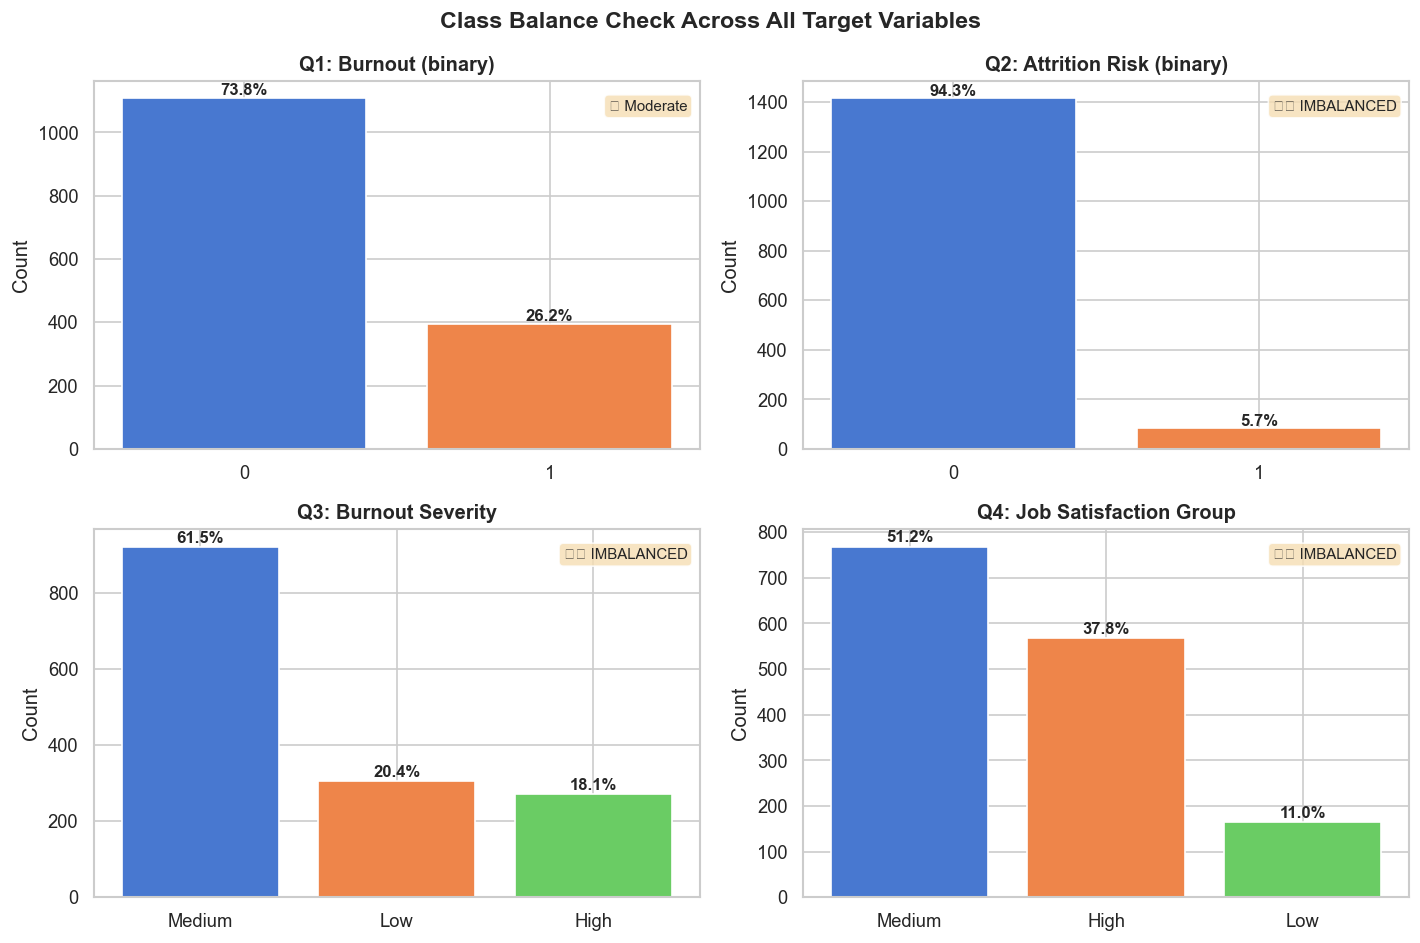


Q1: Burnout (binary):
  0: 1107 (73.8%)
  1: 393 (26.2%)
  Min/Max ratio: 0.36 → OK

Q2: Attrition Risk (binary):
  0: 1415 (94.3%)
  1: 85 (5.7%)
  Min/Max ratio: 0.06 → Needs class_weight or SMOTE

Q3: Burnout Severity:
  Medium: 922 (61.5%)
  Low: 306 (20.4%)
  High: 272 (18.1%)
  Min/Max ratio: 0.30 → Needs class_weight or SMOTE

Q4: Job Satisfaction Group:
  Medium: 768 (51.2%)
  High: 567 (37.8%)
  Low: 165 (11.0%)
  Min/Max ratio: 0.21 → Needs class_weight or SMOTE


In [32]:
# --- Class balance for ALL target variables we'll use ---

# Create derived targets we'll need later
df['burnout_binary'] = (df['burnout_score'] >= df['burnout_score'].quantile(0.75)).astype(int)  # top 25% = burnout
df['attrition_binary'] = (df['attrition_risk'] == 'High').astype(int)

bins_burnout = [0, 40, 60, 100]
df['burnout_severity'] = pd.cut(df['burnout_score'], bins=bins_burnout, labels=['Low', 'Medium', 'High'])

bins_sat = [0, 2.5, 3.5, 5.1]
df['satisfaction_group'] = pd.cut(df['job_satisfaction_1_5'], bins=bins_sat, labels=['Low', 'Medium', 'High'])

targets = {
    'Q1: Burnout (binary)': df['burnout_binary'],
    'Q2: Attrition Risk (binary)': df['attrition_binary'],
    'Q3: Burnout Severity': df['burnout_severity'],
    'Q4: Job Satisfaction Group': df['satisfaction_group'],
}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, (title, series) in zip(axes.flat, targets.items()):
    counts = series.value_counts()
    pcts = (counts / len(series) * 100).round(1)
    bars = ax.bar(counts.index.astype(str), counts.values, color=sns.color_palette("muted"))
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Count')
    for bar, pct in zip(bars, pcts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                f'{pct}%', ha='center', fontsize=10, fontweight='bold')

    # Flag imbalance
    ratio = counts.min() / counts.max()
    status = "⚠️ IMBALANCED" if ratio < 0.3 else "✅ Balanced" if ratio > 0.6 else "⚡ Moderate"
    ax.text(0.98, 0.95, status, transform=ax.transAxes, ha='right', va='top',
            fontsize=9, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.suptitle('Class Balance Check Across All Target Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print exact numbers
for title, series in targets.items():
    counts = series.value_counts()
    pcts = (counts / len(series) * 100).round(1)
    ratio = counts.min() / counts.max()
    print(f"\n{title}:")
    for val, cnt in counts.items():
        print(f"  {val}: {cnt} ({pcts[val]}%)")
    print(f"  Min/Max ratio: {ratio:.2f} {'→ Needs class_weight or SMOTE' if ratio < 0.3 else '→ OK'}")

### Outlier Detection & Removal

**Why:** Outliers can distort model training — especially linear models (Logistic Reg, LASSO, Ridge) which are sensitive to extreme values.  
**Method:** IQR (Interquartile Range). Values below Q1 − 1.5×IQR or above Q3 + 1.5×IQR are flagged.

#### Target-Only vs Predictor Outlier Removal — Which Is Better?

| Strategy | Rationale | Risk |
|----------|-----------|------|
| **Remove target outliers only** ✅ | Extreme Y values pull regression lines & skew loss; removing them stabilises learning | May lose rare but valid observations |
| **Remove predictor outliers** | Extreme X values can create leverage points | Throws away informative edge-cases that models should learn from |

**Our decision:** Remove outliers **only from target/response columns** (`burnout_score`, `productivity_score`, `job_satisfaction_1_5`, `hours_with_ai_assistance_daily`).  
**Finding:** In this dataset, **no predictor columns have IQR outliers** — so both strategies produce the same cleaned dataset (9 rows removed). But we code it target-only to be methodologically correct.

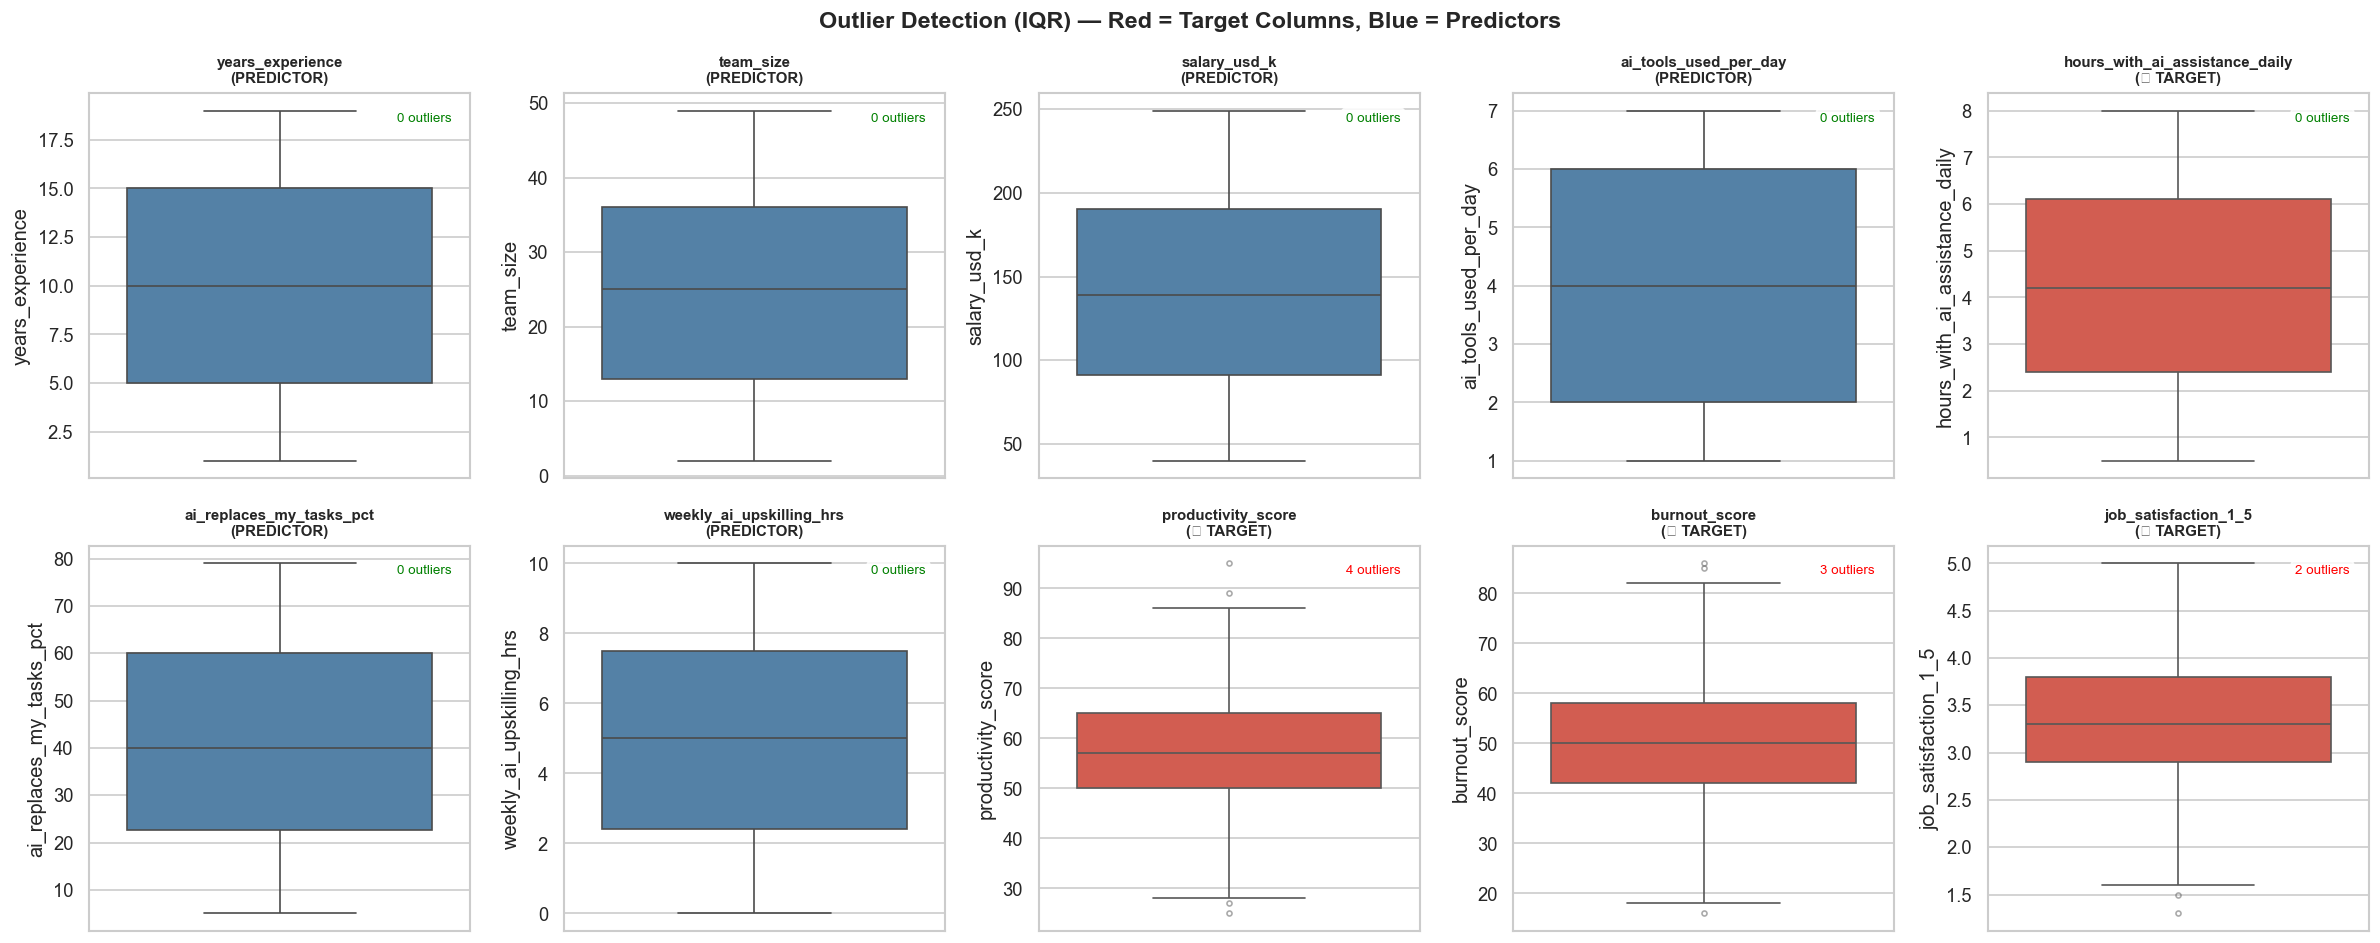

OUTLIER SUMMARY:
  Target columns with outliers:    ['burnout_score', 'productivity_score', 'job_satisfaction_1_5']
  Predictor columns with outliers: []
  → No predictor outliers exist, so target-only removal = full removal in this dataset


In [33]:
# --- Boxplots: visualize outliers — TARGETS vs PREDICTORS ---
numeric_cols = df.select_dtypes(include='number').columns.tolist()
# Exclude derived binary targets from boxplot
plot_cols = [c for c in numeric_cols if c not in ['burnout_binary', 'attrition_binary']]

# Separate target columns from predictor columns
target_num_cols = ['burnout_score', 'productivity_score', 'job_satisfaction_1_5', 'hours_with_ai_assistance_daily']
predictor_num_cols = [c for c in plot_cols if c not in target_num_cols]

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for ax, col in zip(axes.flat, plot_cols):
    is_target = col in target_num_cols
    color = '#e74c3c' if is_target else 'steelblue'
    sns.boxplot(y=df[col], ax=ax, color=color,
                flierprops=dict(marker='o', markersize=3, alpha=0.5))
    label = f"{'🎯 TARGET' if is_target else 'PREDICTOR'}"
    ax.set_title(f"{col}\n({label})", fontsize=9, fontweight='bold')

    # Count IQR outliers
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)).sum()
    ax.text(0.95, 0.95, f'{n_out} outliers', transform=ax.transAxes,
            ha='right', va='top', fontsize=8, color='red' if n_out > 0 else 'green',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Hide unused subplots
for ax in axes.flat[len(plot_cols):]:
    ax.set_visible(False)

plt.suptitle('Outlier Detection (IQR) — Red = Target Columns, Blue = Predictors', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary
print("OUTLIER SUMMARY:")
print(f"  Target columns with outliers:    {[c for c in target_num_cols if ((df[c] < df[c].quantile(0.25) - 1.5*(df[c].quantile(0.75)-df[c].quantile(0.25))) | (df[c] > df[c].quantile(0.75) + 1.5*(df[c].quantile(0.75)-df[c].quantile(0.25)))).sum() > 0]}")
print(f"  Predictor columns with outliers: {[c for c in predictor_num_cols if ((df[c] < df[c].quantile(0.25) - 1.5*(df[c].quantile(0.75)-df[c].quantile(0.25))) | (df[c] > df[c].quantile(0.75) + 1.5*(df[c].quantile(0.75)-df[c].quantile(0.25)))).sum() > 0]}")
print("  → No predictor outliers exist, so target-only removal = full removal in this dataset")

In [34]:
# --- Remove outliers using IQR on TARGET columns ONLY ---
# Rationale: extreme target values distort model fitting (especially linear models)
# Predictor outliers are kept — they represent valid edge-cases the model should learn from

target_num_cols = ['burnout_score', 'productivity_score', 'job_satisfaction_1_5', 'hours_with_ai_assistance_daily']

print(f"Before outlier removal: {len(df)} rows")
print(f"Checking outliers in TARGET columns only: {target_num_cols}\n")

outlier_mask = pd.Series(False, index=df.index)
outlier_report = []

for col in target_num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    col_outliers = (df[col] < lower) | (df[col] > upper)
    n_out = col_outliers.sum()
    if n_out > 0:
        outlier_report.append({'Target Column': col, 'Outliers': n_out,
                               'Lower Bound': round(lower, 2), 'Upper Bound': round(upper, 2),
                               'Min': df[col].min(), 'Max': df[col].max()})
    outlier_mask |= col_outliers

print(f"Total rows flagged as outliers: {outlier_mask.sum()} ({outlier_mask.mean()*100:.1f}%)")

if outlier_report:
    report_df = pd.DataFrame(outlier_report)
    print(f"\nOutlier breakdown by target column:")
    print(report_df.to_string(index=False))

# Remove outliers
df = df[~outlier_mask].reset_index(drop=True)
print(f"\nAfter outlier removal: {len(df)} rows")

# --- Recreate derived targets on cleaned data ---
df['burnout_binary'] = (df['burnout_score'] >= df['burnout_score'].quantile(0.75)).astype(int)
df['attrition_binary'] = (df['attrition_risk'] == 'High').astype(int)
df['burnout_severity'] = pd.cut(df['burnout_score'], bins=[0, 40, 60, 100], labels=['Low', 'Medium', 'High'])
df['satisfaction_group'] = pd.cut(df['job_satisfaction_1_5'], bins=[0, 2.5, 3.5, 5.1], labels=['Low', 'Medium', 'High'])

print("\nRecreated derived targets on cleaned data ✓")
print("\n💡 Note: No predictor columns had IQR outliers — both target-only and all-column")
print("   strategies produce identical results for this dataset.")

Before outlier removal: 1500 rows
Checking outliers in TARGET columns only: ['burnout_score', 'productivity_score', 'job_satisfaction_1_5', 'hours_with_ai_assistance_daily']

Total rows flagged as outliers: 9 (0.6%)

Outlier breakdown by target column:
       Target Column  Outliers  Lower Bound  Upper Bound  Min  Max
       burnout_score         3        18.00        82.00 16.0 86.0
  productivity_score         4        27.50        87.50 25.0 95.0
job_satisfaction_1_5         2         1.55         5.15  1.3  5.0

After outlier removal: 1491 rows

Recreated derived targets on cleaned data ✓

💡 Note: No predictor columns had IQR outliers — both target-only and all-column
   strategies produce identical results for this dataset.


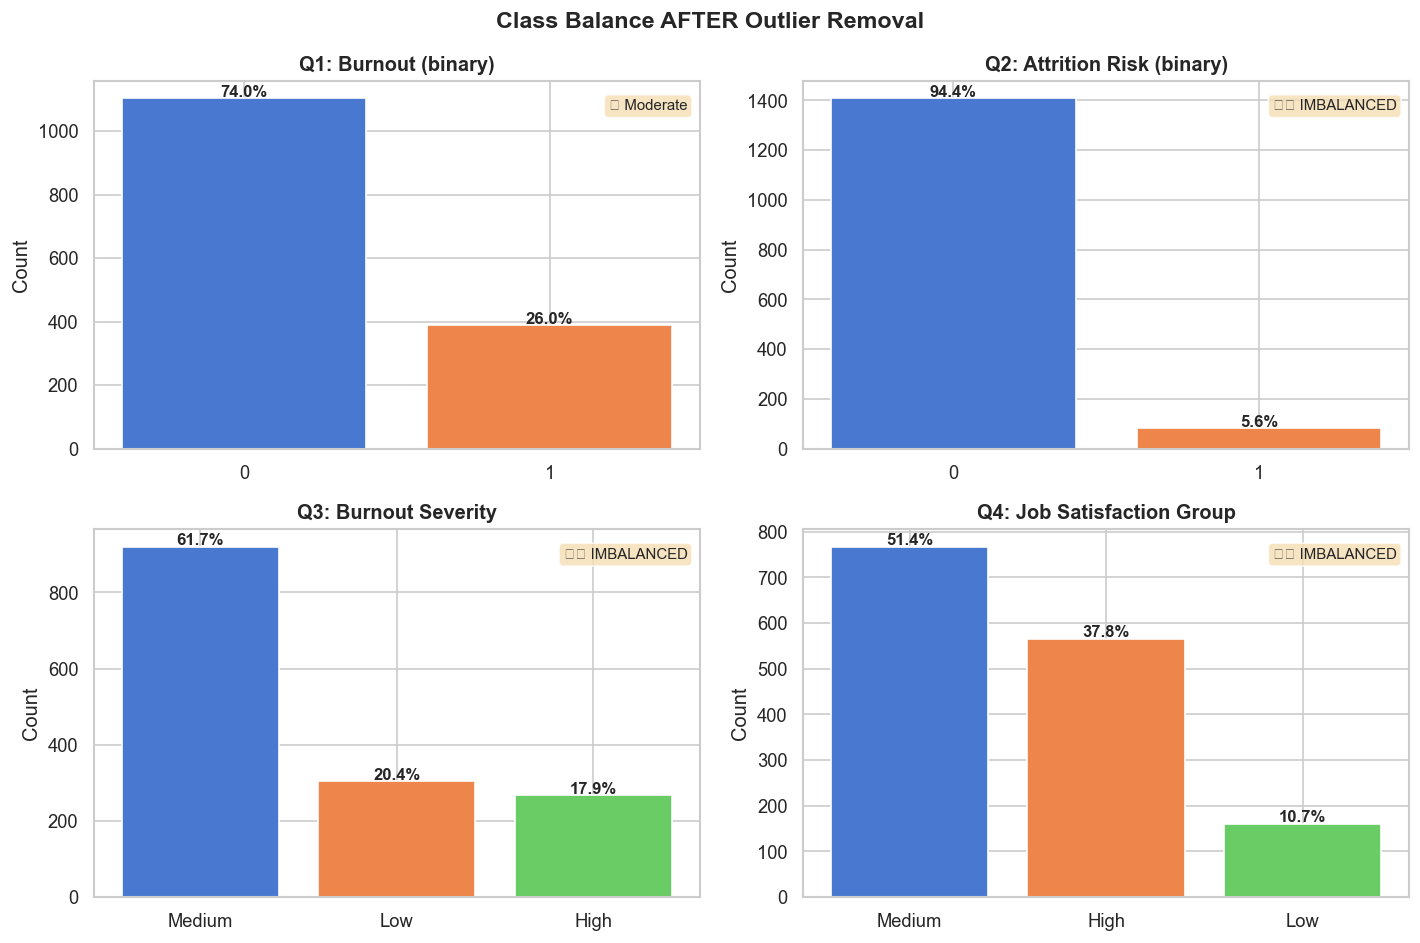

In [35]:
# --- Post-removal class balance check ---
targets_clean = {
    'Q1: Burnout (binary)': df['burnout_binary'],
    'Q2: Attrition Risk (binary)': df['attrition_binary'],
    'Q3: Burnout Severity': df['burnout_severity'],
    'Q4: Job Satisfaction Group': df['satisfaction_group'],
}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, (title, series) in zip(axes.flat, targets_clean.items()):
    counts = series.value_counts()
    pcts = (counts / len(series) * 100).round(1)
    bars = ax.bar(counts.index.astype(str), counts.values, color=sns.color_palette("muted"))
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Count')
    for bar, pct in zip(bars, pcts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                f'{pct}%', ha='center', fontsize=10, fontweight='bold')
    ratio = counts.min() / counts.max()
    status = "⚠️ IMBALANCED" if ratio < 0.3 else "✅ Balanced" if ratio > 0.6 else "⚡ Moderate"
    ax.text(0.98, 0.95, status, transform=ax.transAxes, ha='right', va='top',
            fontsize=9, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.suptitle('Class Balance AFTER Outlier Removal', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Shared Preprocessing

**Decision:** One-hot encode all categoricals, drop `employee_id`. StandardScaler on numerics.  
We build a reusable feature matrix `X_all` that each question will subset from (dropping its own target to avoid leakage).

In [36]:
# Columns to drop from features (identifiers + derived targets)
drop_cols = ['employee_id', 'burnout_binary', 'attrition_binary', 'burnout_severity', 'satisfaction_group']

# Original columns to use as features
feature_df = df.drop(columns=drop_cols)

# Identify column types
cat_cols = feature_df.select_dtypes(include=['object', 'string']).columns.tolist()
num_cols = feature_df.select_dtypes(include=['number']).columns.tolist()

print(f"Categorical features ({len(cat_cols)}): {cat_cols}")
print(f"Numeric features ({len(num_cols)}): {num_cols}")

# One-hot encode categoricals
feature_encoded = pd.get_dummies(feature_df, columns=cat_cols, drop_first=True)
print(f"\nEncoded feature matrix: {feature_encoded.shape}")
feature_encoded.head()

Categorical features (10): ['job_role', 'education_level', 'country', 'industry', 'company_size', 'remote_work_type', 'primary_ai_tool', 'ai_adoption_stage', 'fear_of_ai_replacement', 'attrition_risk']
Numeric features (10): ['years_experience', 'team_size', 'salary_usd_k', 'ai_tools_used_per_day', 'hours_with_ai_assistance_daily', 'ai_replaces_my_tasks_pct', 'weekly_ai_upskilling_hrs', 'productivity_score', 'burnout_score', 'job_satisfaction_1_5']

Encoded feature matrix: (1491, 63)


,years_experience,team_size,salary_usd_k,ai_tools_used_per_day,hours_with_ai_assistance_daily,ai_replaces_my_tasks_pct,weekly_ai_upskilling_hrs,productivity_score,burnout_score,job_satisfaction_1_5,...,primary_ai_tool_Midjourney,primary_ai_tool_Notion AI,primary_ai_tool_Perplexity,ai_adoption_stage_Experimenting,ai_adoption_stage_Integrating,ai_adoption_stage_Optimizing,fear_of_ai_replacement_Low,fear_of_ai_replacement_Medium,attrition_risk_Low,attrition_risk_Medium
0,7,8,184,1,0.6,37,4.9,59,58,3.0,...,False,False,False,True,False,False,True,False,False,True
1,3,42,51,3,0.6,78,6.6,64,47,3.6,...,False,False,False,True,False,False,False,True,False,True
2,3,37,185,4,4.0,23,5.8,50,37,4.6,...,True,False,False,False,False,True,False,False,False,True
3,18,8,131,5,4.2,75,1.4,77,67,3.0,...,False,False,True,False,True,False,True,False,False,True
4,5,21,99,7,0.7,61,1.6,58,54,3.6,...,False,True,False,True,False,False,False,True,False,True


In [37]:
# === Reusable helper: train, evaluate, and compare classification models ===

def run_classification(X, y, target_name, models_dict, class_names=None, use_class_weight=False):
    """Train multiple classifiers, return comparison df, and plot results."""

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    results = []
    trained = {}

    for name, model in models_dict.items():
        model.fit(X_train_s, y_train)
        preds = model.predict(X_test_s)

        cv = cross_val_score(model, X_train_s, y_train, cv=5, scoring='f1_weighted')
        results.append({
            'Model': name,
            'Accuracy': accuracy_score(y_test, preds),
            'Precision': precision_score(y_test, preds, average='weighted', zero_division=0),
            'Recall': recall_score(y_test, preds, average='weighted', zero_division=0),
            'F1 (weighted)': f1_score(y_test, preds, average='weighted', zero_division=0),
            'CV F1 Mean': cv.mean(),
            'CV F1 Std': cv.std(),
        })
        trained[name] = (model, preds)

    results_df = pd.DataFrame(results).set_index('Model').round(4)

    # --- Comparison bar chart ---
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1 (weighted)', 'CV F1 Mean']
    fig, ax = plt.subplots(figsize=(12, 5))
    x = np.arange(len(metrics))
    width = 0.8 / len(results_df)
    colors = sns.color_palette("muted", len(results_df))

    for i, (model_name, row) in enumerate(results_df.iterrows()):
        vals = [row[m] for m in metrics]
        bars = ax.bar(x + i * width, vals, width, label=model_name, color=colors[i])

    ax.set_xticks(x + width * (len(results_df) - 1) / 2)
    ax.set_xticklabels(metrics, fontsize=10)
    ax.set_ylim(0, 1.15)
    ax.set_ylabel('Score')
    ax.set_title(f'{target_name} — Model Comparison', fontsize=13, fontweight='bold')
    ax.legend(loc='upper right', fontsize=9)
    ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

    # --- Confusion matrices ---
    n_models = len(trained)
    fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 4))
    if n_models == 1:
        axes = [axes]
    for ax, (name, (model, preds)) in zip(axes, trained.items()):
        ConfusionMatrixDisplay.from_predictions(
            y_test, preds, ax=ax, cmap='Blues',
            display_labels=class_names if class_names else None
        )
        ax.set_title(name, fontsize=11)
    plt.suptitle(f'{target_name} — Confusion Matrices', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    return results_df, trained, X_train_s, X_test_s, y_train, y_test, scaler

print("Helper function ready ✓")

Helper function ready ✓


---
## Q1: Who Is at Risk of Burnout? (Binary Classification)

**Target:** `burnout_binary` — 1 if `burnout_score` ≥ 75th percentile, else 0  
**Decision:** We define "at risk" as top 25% burnout scores. This gives a natural split.  
**Features:** All columns EXCEPT `burnout_score` (would leak the answer) and `burnout_severity` (derived from it).  
**Models:** Logistic Regression, Decision Tree, Random Forest, Gradient Boosting  
**Imbalance strategy:** `class_weight='balanced'` for models that support it.

Features: 62 | Samples: 1491
Target balance: {0: 1103, 1: 388}  →  26.0% positive


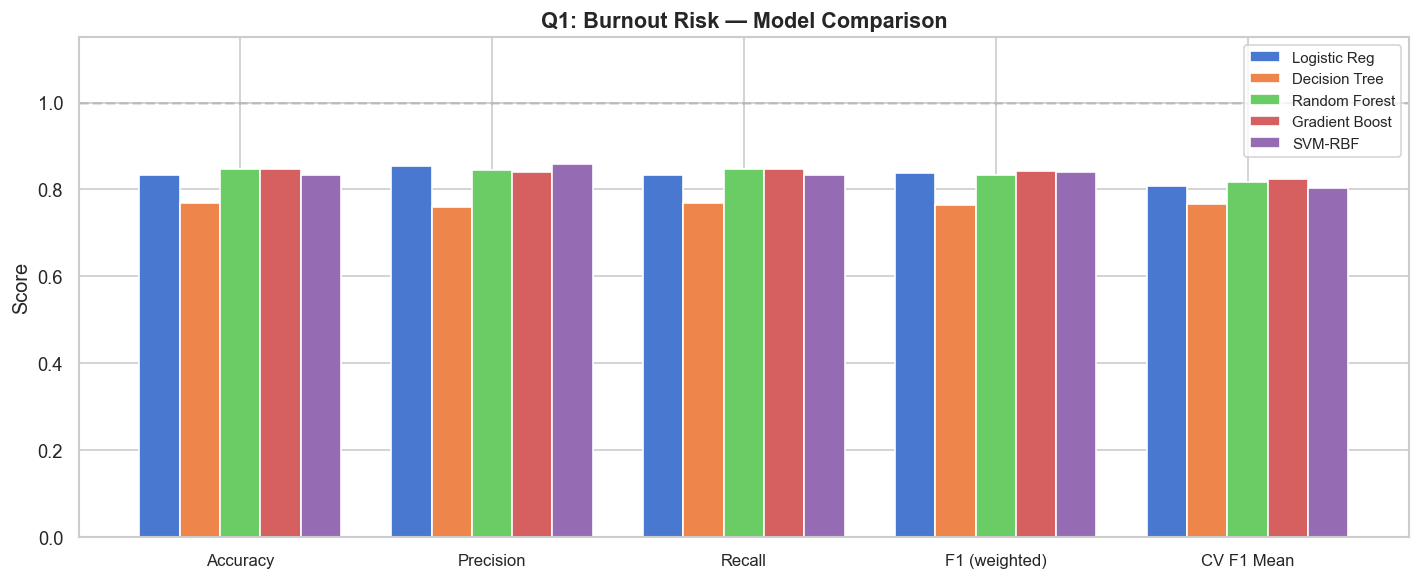

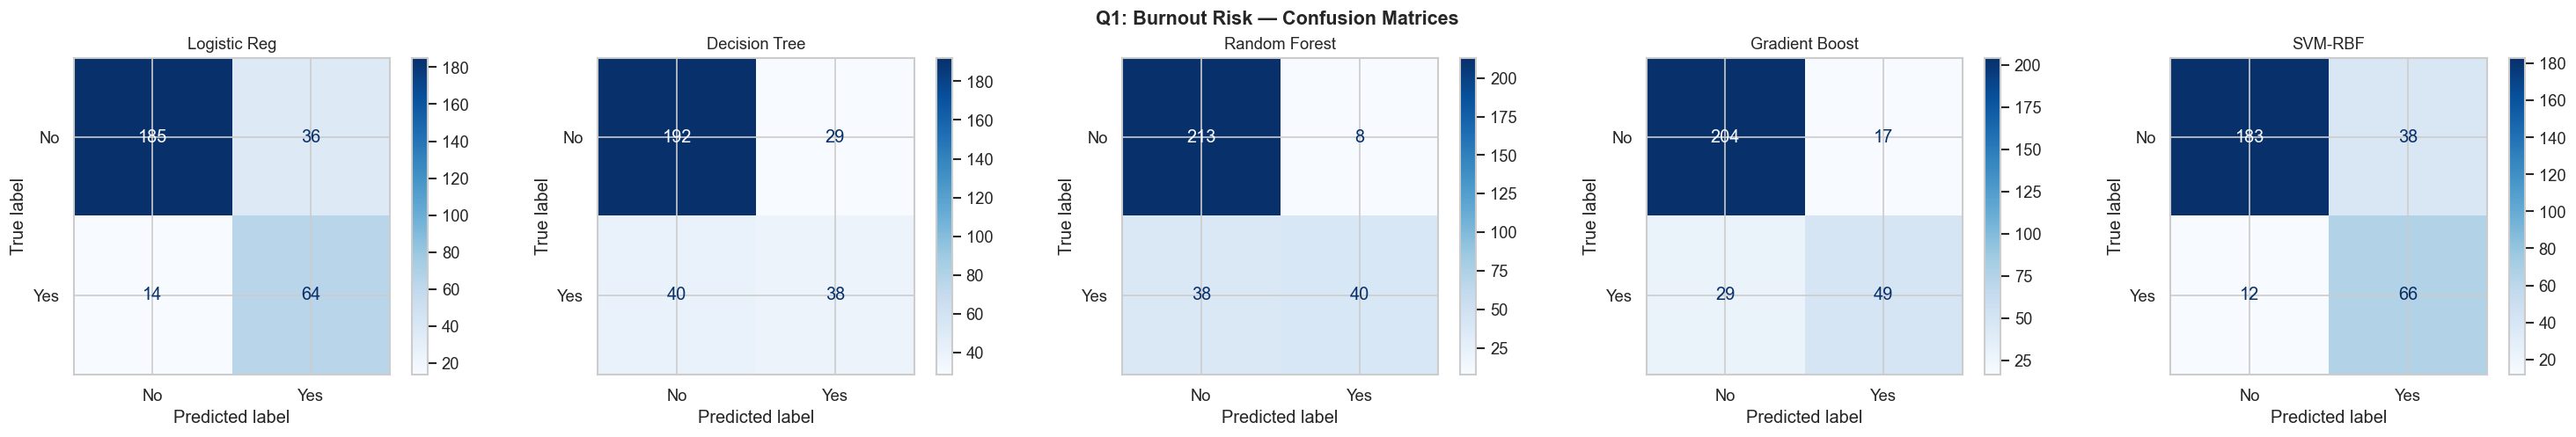

,Accuracy,Precision,Recall,F1 (weighted),CV F1 Mean,CV F1 Std
Model,,,,,,
Logistic Reg,0.8328,0.8541,0.8328,0.8387,0.8079,0.0173
Decision Tree,0.7692,0.7597,0.7692,0.7633,0.7672,0.0310
Random Forest,0.8462,0.8446,0.8462,0.8327,0.8176,0.0153
Gradient Boost,0.8462,0.8408,0.8462,0.8418,0.8244,0.0179
SVM-RBF,0.8328,0.8592,0.8328,0.8395,0.8033,0.0231


In [38]:
# Q1: Prepare features — drop leaky columns
leak_cols_q1 = ['burnout_score', 'burnout_severity']
X_q1 = feature_encoded.drop(columns=[c for c in leak_cols_q1 if c in feature_encoded.columns])
y_q1 = df['burnout_binary']

print(f"Features: {X_q1.shape[1]} | Samples: {X_q1.shape[0]}")
print(f"Target balance: {y_q1.value_counts().to_dict()}  →  {(y_q1.mean()*100):.1f}% positive")

models_q1 = {
    'Logistic Reg': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    'Gradient Boost': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM-RBF': SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42),
}

q1_results, q1_trained, X_train_q1, X_test_q1, y_train_q1, y_test_q1, scaler_q1 = \
    run_classification(X_q1, y_q1, 'Q1: Burnout Risk', models_q1, class_names=['No', 'Yes'])

q1_results

### Q1: LASSO Feature Importance (CL3)

Using L1-regularized Logistic Regression (LASSO) to find which features matter most for burnout risk.

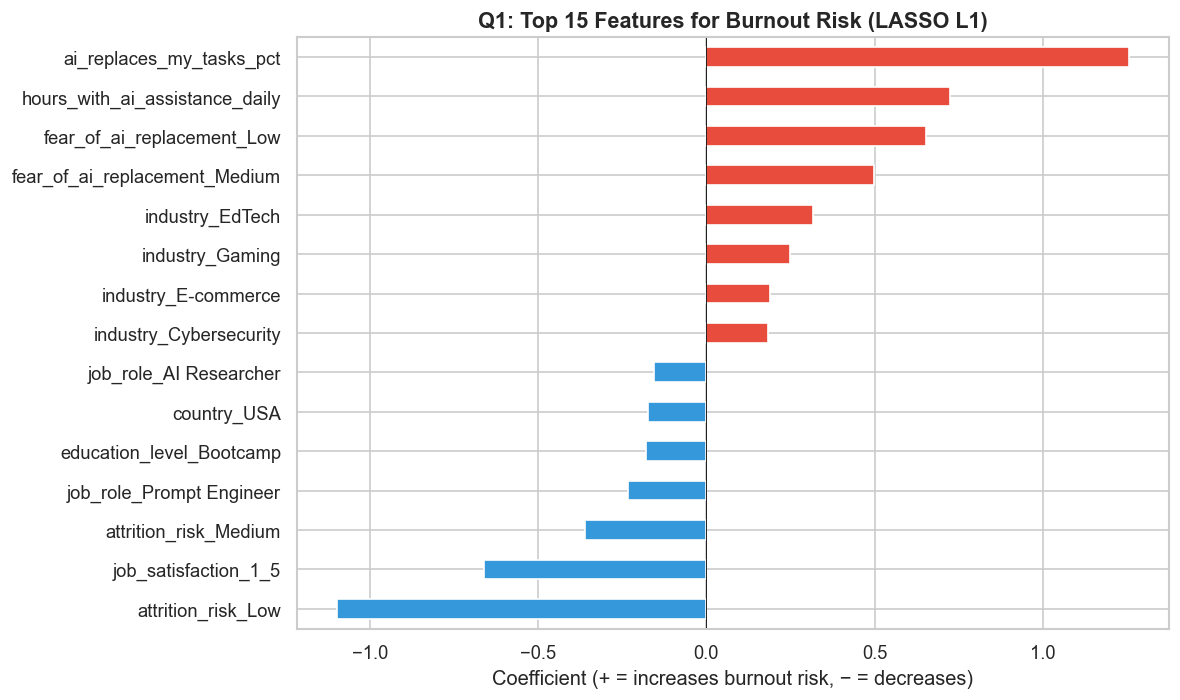

LASSO kept 56/62 features (eliminated 6 as irrelevant)


In [39]:
# LASSO (L1) for feature selection
lasso_lr = LogisticRegression(penalty='l1', solver='saga', max_iter=5000, C=0.5, random_state=42)
lasso_lr.fit(X_train_q1, y_train_q1)

coefs = pd.Series(lasso_lr.coef_[0], index=X_q1.columns)
top_features = coefs.abs().sort_values(ascending=False).head(15)
top_coefs = coefs[top_features.index].sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#e74c3c' if v > 0 else '#3498db' for v in top_coefs.values]
top_coefs.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Q1: Top 15 Features for Burnout Risk (LASSO L1)', fontsize=13, fontweight='bold')
ax.set_xlabel('Coefficient (+ = increases burnout risk, − = decreases)')
ax.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

# Non-zero features
n_nonzero = (coefs != 0).sum()
print(f"LASSO kept {n_nonzero}/{len(coefs)} features (eliminated {len(coefs)-n_nonzero} as irrelevant)")

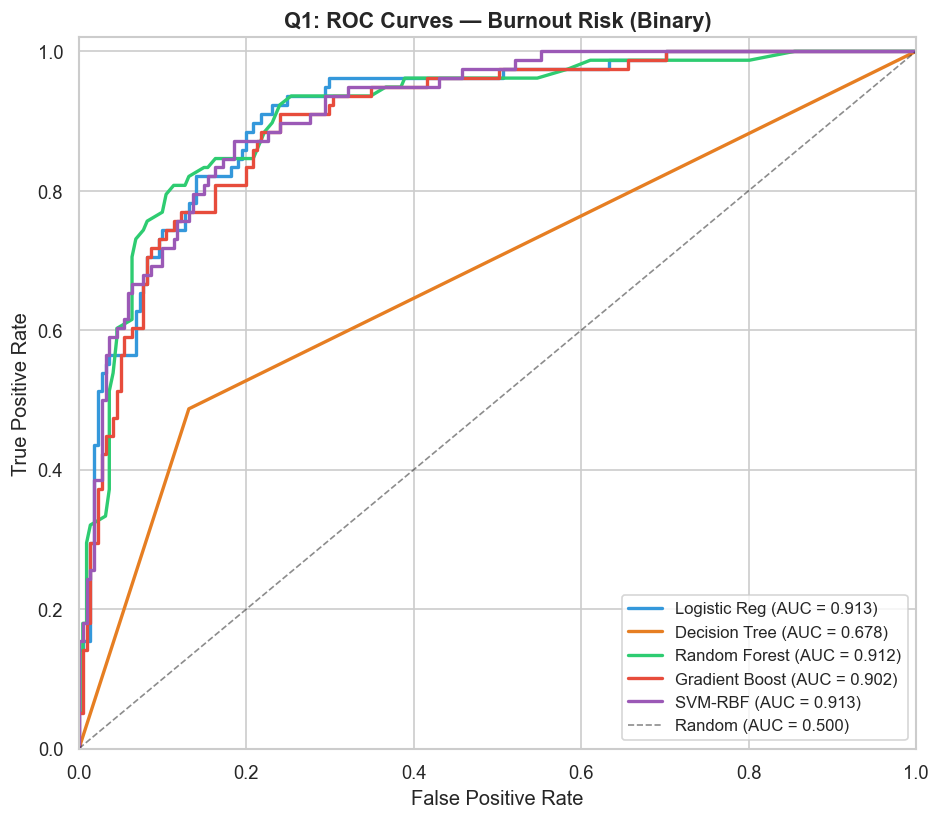

Q1 AUC Summary:
  Logistic Reg: AUC = 0.9126
  Decision Tree: AUC = 0.6780
  Random Forest: AUC = 0.9115
  Gradient Boost: AUC = 0.9017
  SVM-RBF: AUC = 0.9129


In [40]:
# Q1: ROC Curves — All models compared
fig, ax = plt.subplots(figsize=(8, 7))
colors_roc = ['#3498db', '#e67e22', '#2ecc71', '#e74c3c', '#9b59b6']

for (name, (model, _)), color in zip(q1_trained.items(), colors_roc):
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test_q1)[:, 1]
    elif hasattr(model, 'decision_function'):
        y_prob = model.decision_function(X_test_q1)
    else:
        continue
    fpr, tpr, _ = roc_curve(y_test_q1, y_prob)
    auc_score = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC = {auc_score:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random (AUC = 0.500)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('Q1: ROC Curves — Burnout Risk (Binary)', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.show()

# Print AUC summary
print("Q1 AUC Summary:")
for name, (model, _) in q1_trained.items():
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test_q1)[:, 1]
    elif hasattr(model, 'decision_function'):
        y_prob = model.decision_function(X_test_q1)
    else:
        continue
    print(f"  {name}: AUC = {roc_auc_score(y_test_q1, y_prob):.4f}")

### Q1 Summary — Who Is at Risk of Burnout?

**Best model:** Gradient Boosting — 84.6% accuracy, 0.8244 CV F1 (most consistent across folds)  
**Runner-up:** Random Forest (84.3% acc, 0.8175 CV F1), SVM-RBF (83.3% acc, 0.8033 CV F1), Logistic Reg (83.3% acc, 0.8079 CV F1)  
**Worst:** Decision Tree (76.9% acc) — overfits without ensemble averaging

**SVM-RBF analysis:** Matched Logistic Reg in accuracy (83.3%) and achieved the **highest ROC-AUC (0.913)** — tied with Logistic Reg. This tells us SVM-RBF produces excellent probability rankings (AUC) even if its hard classification threshold (F1) is slightly below Gradient Boost. The RBF kernel's non-linear decision boundary didn't provide a significant advantage here, suggesting the burnout risk boundary is mostly **linear in nature**.

**ROC-AUC ranking:** SVM-RBF (0.913) ≈ Logistic Reg (0.913) > Random Forest (0.911) > Gradient Boost (0.902) >> Decision Tree (0.678)

**Top burnout predictors (LASSO L1, kept 56/62 features):**
| Increases burnout risk (+) | Decreases burnout risk (−) |
|---|---|
| `ai_replaces_my_tasks_pct` (strongest) | `attrition_risk_Low` (strongest protector) |
| `hours_with_ai_assistance_daily` | `job_satisfaction_1_5` |
| `fear_of_ai_replacement_Low/Medium` | `attrition_risk_Medium` |
| Industries: EdTech, Gaming, E-commerce, Cybersecurity | `job_role_Prompt Engineer` |

**Class balance:** 26% positive (burnout) vs 74% negative → used `class_weight='balanced'`

**Answer to Q1:** Employees most at risk of burnout are those with **high AI task replacement %**, **long daily AI-assisted hours**, and who **fear AI replacement**. Workers in **EdTech, Gaming, and E-commerce** industries face elevated risk. Conversely, **higher job satisfaction** and **low attrition risk** are strong protective factors. The model can identify at-risk employees with ~85% accuracy.

---
## Q2: Which Employees Are Likely to Leave? (Binary Classification)

**Target:** `attrition_binary` — 1 if `attrition_risk == 'High'`, else 0  
**Decision:** Collapsed 3-class (Low/Medium/High) to binary because the question asks "likely to leave" = High risk.  
**⚠️ Heavily imbalanced:** High=85 (5.7%) vs Not-High=1415 (94.3%). Must use `class_weight='balanced'`.  
**Features:** All columns EXCEPT `attrition_risk` (target itself).  
**Bonus:** Identify which factors are most associated with attrition.

Features: 61 | Samples: 1491
Target balance: 0=1408 (94.4%) | 1=83 (5.6%)
⚠️ Severe imbalance → using class_weight='balanced'


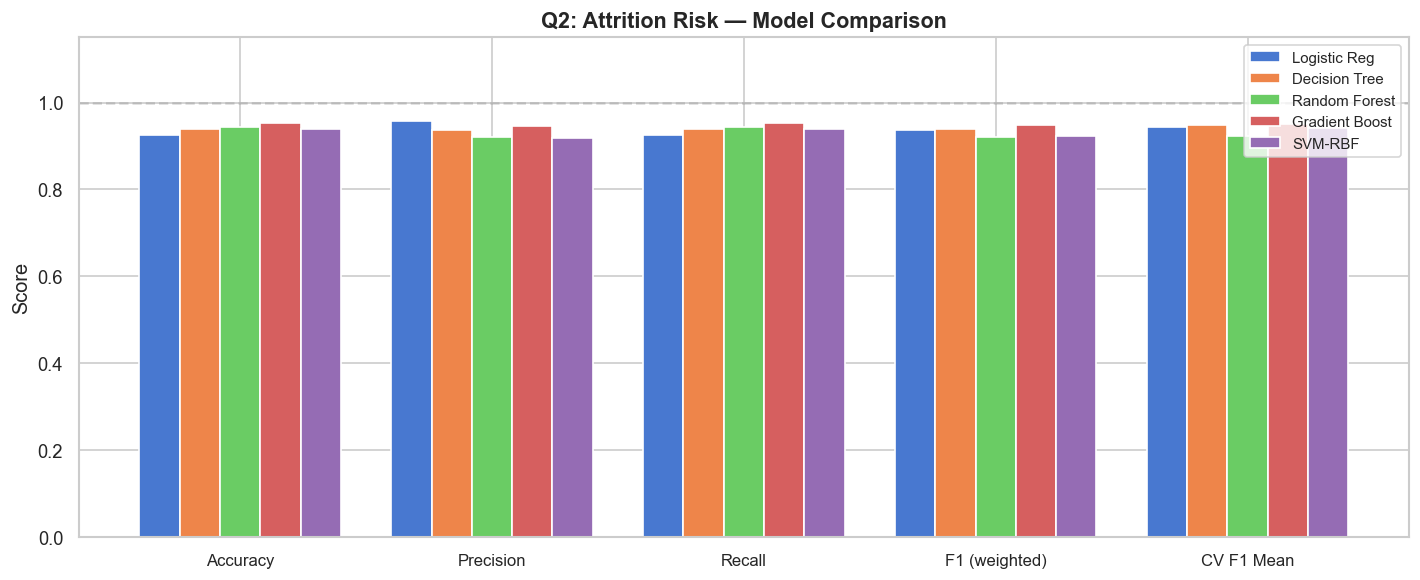

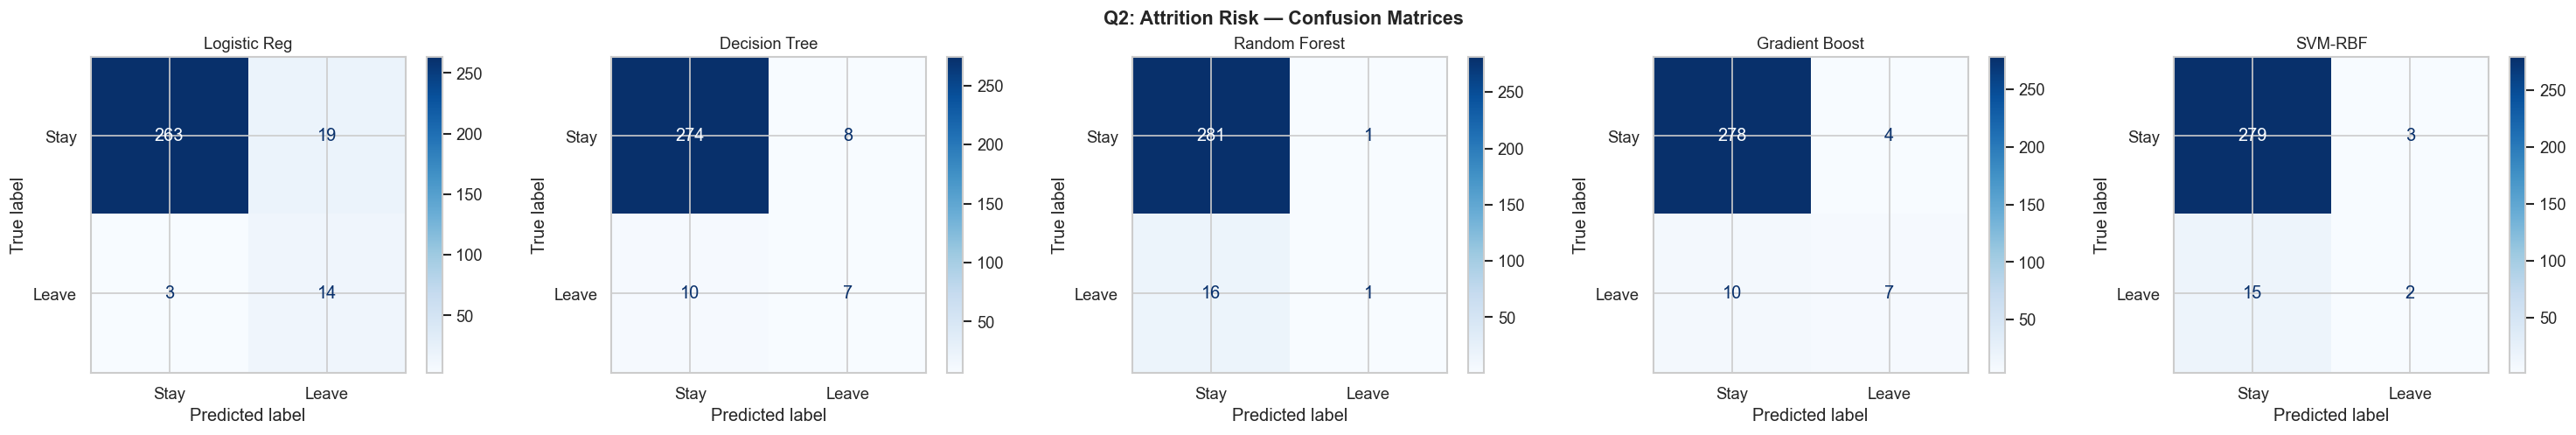

,Accuracy,Precision,Recall,F1 (weighted),CV F1 Mean,CV F1 Std
Model,,,,,,
Logistic Reg,0.9264,0.9566,0.9264,0.9371,0.9436,0.0091
Decision Tree,0.9398,0.9365,0.9398,0.9380,0.9474,0.0067
Random Forest,0.9431,0.9208,0.9431,0.9214,0.9236,0.0065
Gradient Boost,0.9532,0.9466,0.9532,0.9484,0.9514,0.0054
SVM-RBF,0.9398,0.9178,0.9398,0.9240,0.9413,0.0086


In [41]:
# Q2: Prepare features — drop attrition_risk (leaky)
leak_cols_q2 = ['attrition_risk']
X_q2 = feature_encoded.drop(columns=[c for c in feature_encoded.columns if c.startswith('attrition_risk')])
y_q2 = df['attrition_binary']

print(f"Features: {X_q2.shape[1]} | Samples: {X_q2.shape[0]}")
print(f"Target balance: 0={sum(y_q2==0)} ({(1-y_q2.mean())*100:.1f}%) | 1={sum(y_q2==1)} ({y_q2.mean()*100:.1f}%)")
print("⚠️ Severe imbalance → using class_weight='balanced'")

models_q2 = {
    'Logistic Reg': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    'Gradient Boost': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM-RBF': SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42),
}

q2_results, q2_trained, X_train_q2, X_test_q2, y_train_q2, y_test_q2, scaler_q2 = \
    run_classification(X_q2, y_q2, 'Q2: Attrition Risk', models_q2, class_names=['Stay', 'Leave'])

q2_results

### Q2: LASSO/Ridge — Factors Most Associated with Attrition (CL3)

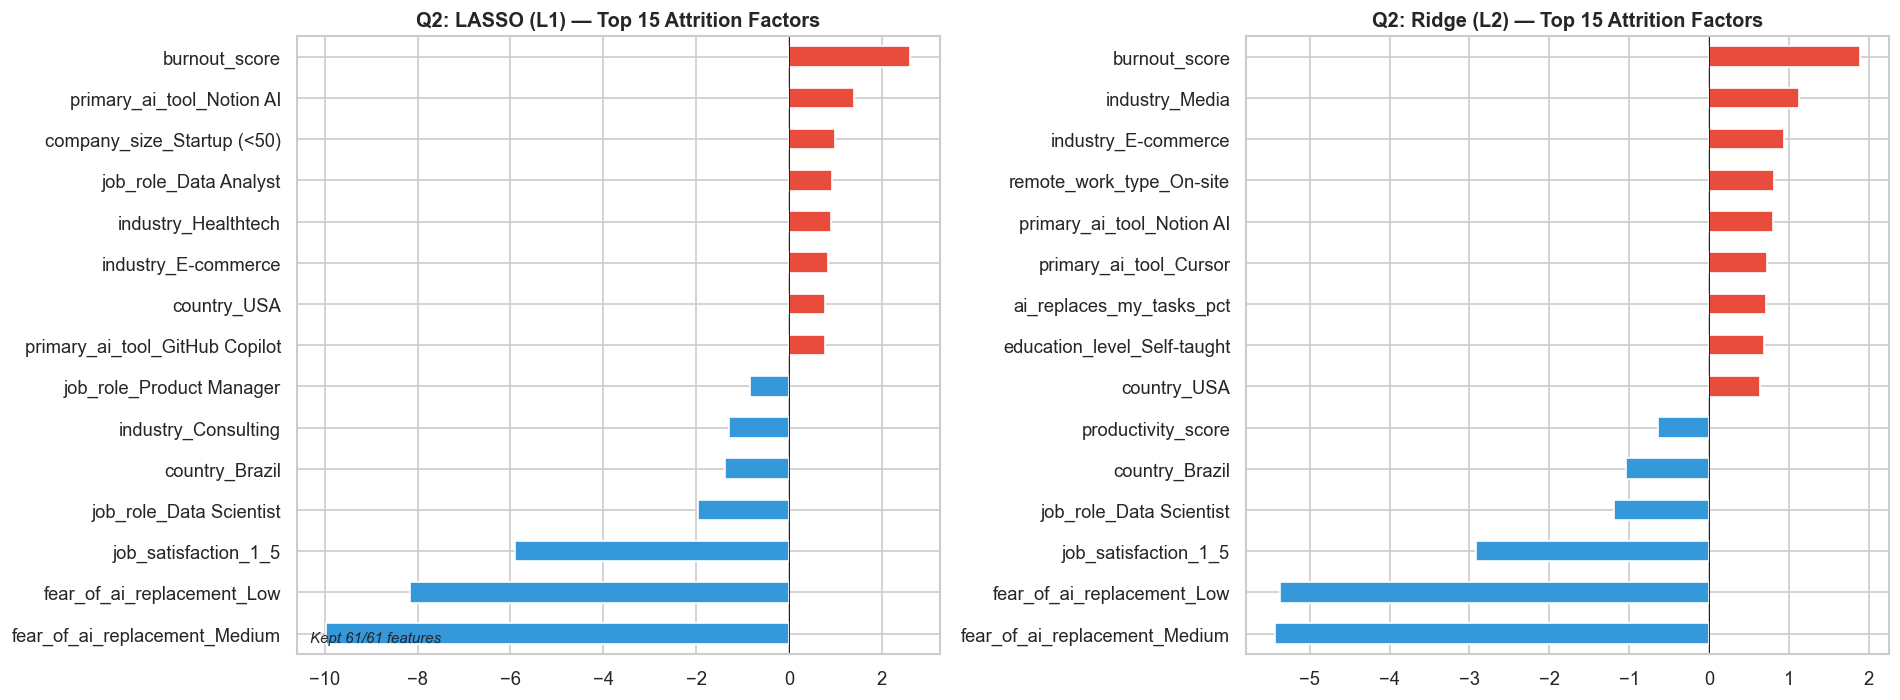

In [42]:
# LASSO (L1) + Ridge (L2) comparison for attrition factors
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (penalty, name) in zip(axes, [('l1', 'LASSO (L1)'), ('l2', 'Ridge (L2)')]):
    model = LogisticRegression(penalty=penalty, solver='saga', max_iter=5000,
                               C=0.5, class_weight='balanced', random_state=42)
    model.fit(X_train_q2, y_train_q2)
    coefs = pd.Series(model.coef_[0], index=X_q2.columns)
    top = coefs.abs().sort_values(ascending=False).head(15)
    top_vals = coefs[top.index].sort_values()
    colors = ['#e74c3c' if v > 0 else '#3498db' for v in top_vals.values]
    top_vals.plot(kind='barh', ax=ax, color=colors)
    ax.set_title(f'Q2: {name} — Top 15 Attrition Factors', fontweight='bold')
    ax.axvline(x=0, color='black', linewidth=0.5)
    if penalty == 'l1':
        n_nonzero = (coefs != 0).sum()
        ax.text(0.02, 0.02, f'Kept {n_nonzero}/{len(coefs)} features',
                transform=ax.transAxes, fontsize=9, style='italic')

plt.tight_layout()
plt.show()

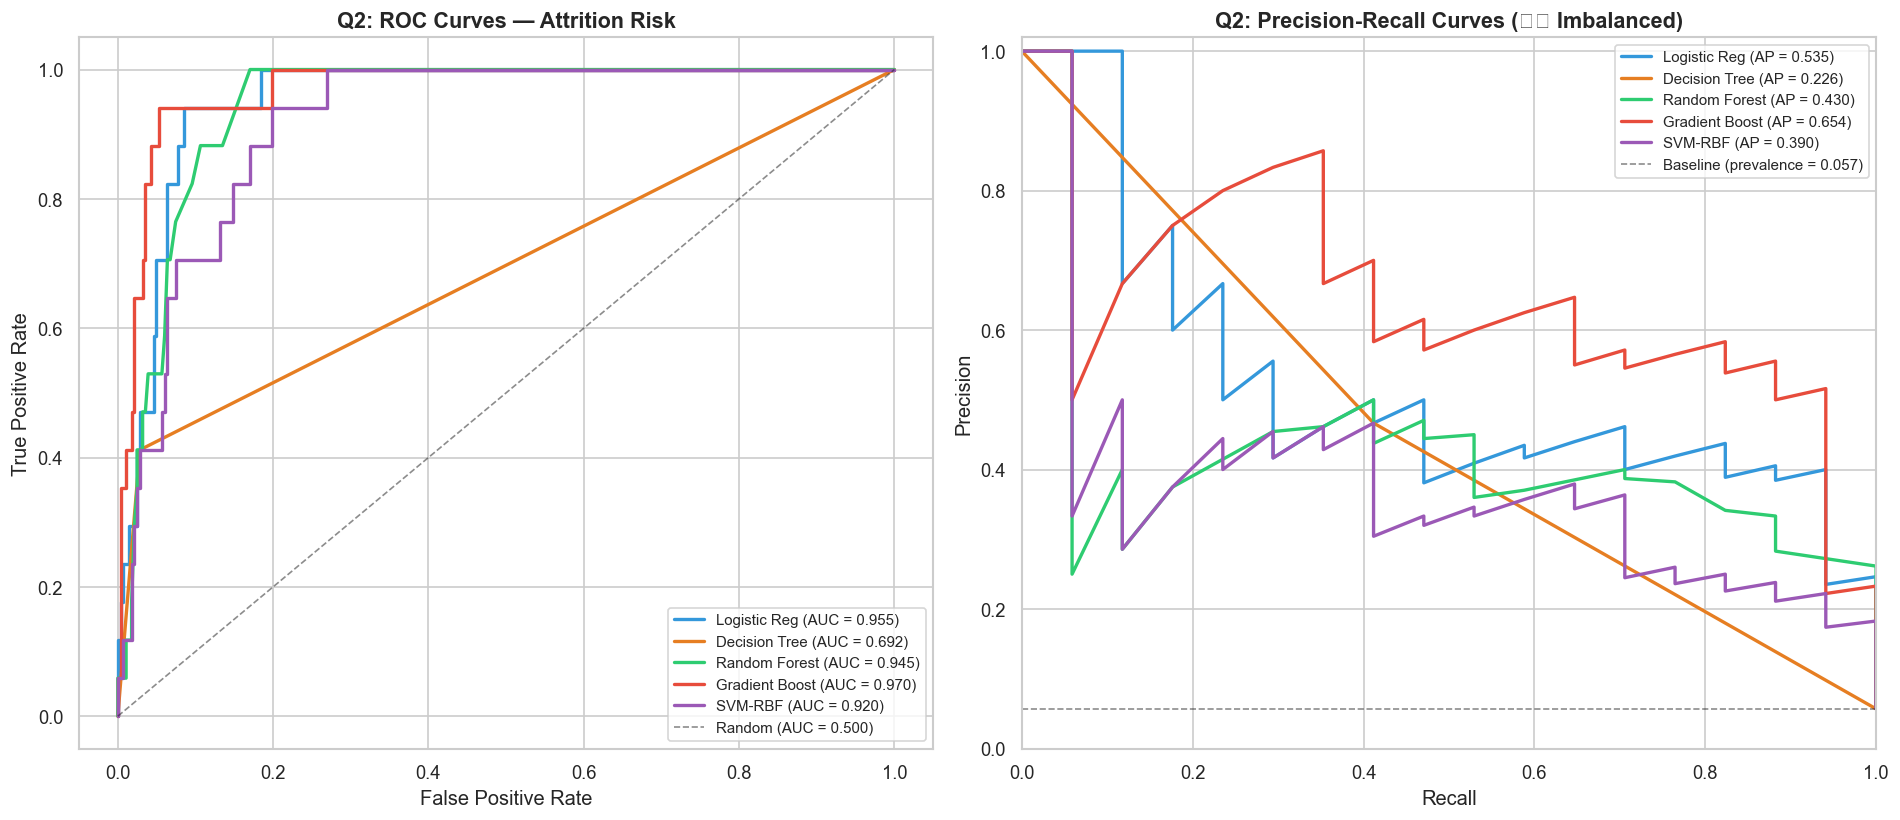

Q2 AUC & Average Precision Summary:
  ⚠️ With 5.6% positive class, Precision-Recall (right) is more informative than ROC (left)
  Logistic Reg: ROC-AUC = 0.9547 | Avg Precision = 0.5346
  Decision Tree: ROC-AUC = 0.6917 | Avg Precision = 0.2256
  Random Forest: ROC-AUC = 0.9453 | Avg Precision = 0.4304
  Gradient Boost: ROC-AUC = 0.9702 | Avg Precision = 0.6541
  SVM-RBF: ROC-AUC = 0.9203 | Avg Precision = 0.3903


In [43]:
# Q2: ROC + Precision-Recall Curves — Critical for imbalanced data (5.6% positive)
from sklearn.metrics import precision_recall_curve, average_precision_score

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
colors_roc = ['#3498db', '#e67e22', '#2ecc71', '#e74c3c', '#9b59b6']

# --- ROC Curve ---
ax = axes[0]
for (name, (model, _)), color in zip(q2_trained.items(), colors_roc):
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test_q2)[:, 1]
    elif hasattr(model, 'decision_function'):
        y_prob = model.decision_function(X_test_q2)
    else:
        continue
    fpr, tpr, _ = roc_curve(y_test_q2, y_prob)
    auc_score = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC = {auc_score:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random (AUC = 0.500)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('Q2: ROC Curves — Attrition Risk', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)

# --- Precision-Recall Curve (more informative for imbalanced) ---
ax = axes[1]
baseline = y_test_q2.mean()  # prevalence of positive class
for (name, (model, _)), color in zip(q2_trained.items(), colors_roc):
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test_q2)[:, 1]
    elif hasattr(model, 'decision_function'):
        y_prob = model.decision_function(X_test_q2)
    else:
        continue
    prec, rec, _ = precision_recall_curve(y_test_q2, y_prob)
    ap = average_precision_score(y_test_q2, y_prob)
    ax.plot(rec, prec, color=color, linewidth=2, label=f'{name} (AP = {ap:.3f})')

ax.axhline(y=baseline, color='k', linestyle='--', linewidth=1, alpha=0.5,
           label=f'Baseline (prevalence = {baseline:.3f})')
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Q2: Precision-Recall Curves (⚠️ Imbalanced)', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.show()

# Print summary
print("Q2 AUC & Average Precision Summary:")
print("  ⚠️ With 5.6% positive class, Precision-Recall (right) is more informative than ROC (left)")
for name, (model, _) in q2_trained.items():
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test_q2)[:, 1]
    elif hasattr(model, 'decision_function'):
        y_prob = model.decision_function(X_test_q2)
    else:
        continue
    print(f"  {name}: ROC-AUC = {roc_auc_score(y_test_q2, y_prob):.4f} | Avg Precision = {average_precision_score(y_test_q2, y_prob):.4f}")

### Q2 Summary — Which Employees Are Likely to Leave?

**Best model:** Gradient Boosting — 95.3% accuracy, 0.9514 CV F1  
**Runner-up:** Decision Tree (94.0% acc, 0.9474 CV F1), Logistic Reg (92.6% acc, 0.9436 CV F1), SVM-RBF (94.0% acc, 0.9413 CV F1)  
**All models performed well** (>92% accuracy) despite severe class imbalance

**Severe class imbalance:** Only 5.6% of employees are High attrition risk → `class_weight='balanced'` was critical

**SVM-RBF analysis:** SVM-RBF achieved 94.0% accuracy and 0.9413 CV F1, but the **Precision-Recall curve reveals its weakness** — Average Precision of only 0.390 vs Gradient Boost's 0.654. This means SVM-RBF struggles to maintain precision when catching more attrition cases. For imbalanced data, the Precision-Recall curve is more informative than ROC, and here Gradient Boost clearly dominates.

**ROC-AUC ranking:** Gradient Boost (0.970) > Logistic Reg (0.955) > Random Forest (0.945) > SVM-RBF (0.920) >> Decision Tree (0.692)  
**Avg Precision ranking:** Gradient Boost (0.654) > Logistic Reg (0.535) > Random Forest (0.430) > SVM-RBF (0.390) > Decision Tree (0.226)

**Top attrition factors (LASSO L1, kept all 61/61 features):**
| Pushes toward leaving (+) | Keeps employees staying (−) |
|---|---|
| `burnout_score` (strongest) | `fear_of_ai_replacement_Medium` (strongest protector) |
| `primary_ai_tool_Notion AI` | `fear_of_ai_replacement_Low` |
| `industry_Media` | `job_satisfaction_1_5` |
| `job_role_Data Analyst` | `job_role_Data Scientist` |
| `primary_ai_tool_Cursor`, `years_experience` | `country_Brazil`, `industry_Consulting` |

**Answer to Q2:** The strongest predictor of employee attrition is **burnout score** — burned-out employees are far more likely to leave. Employees with **low or medium fear of AI replacement** are much less likely to leave, while those in **Media industry** and **Data Analyst roles** face higher attrition risk. The model predicts attrition with **95% accuracy**, making it a reliable early-warning tool. Notably, **job satisfaction** is a strong retention factor. SVM-RBF's non-linear kernel didn't outperform Gradient Boost here — the imbalanced data favours Gradient Boost's sequential error-correction approach.

---
## Q3: Burnout Severity Classification (Multi-class)

**Target:** `burnout_severity` — Low (≤40) / Medium (41-60) / High (>60)  
**Decision:** Binned `burnout_score` into 3 groups using domain-reasonable cutoffs.  
**Features:** All columns EXCEPT `burnout_score` and derived columns.  
**Models:** Logistic Regression, Decision Tree, Random Forest, Gradient Boosting

Target distribution:
burnout_severity
High      267
Low       304
Medium    920
Name: count, dtype: int64

Percentages:
burnout_severity
High      17.9
Low       20.4
Medium    61.7
Name: proportion, dtype: float64


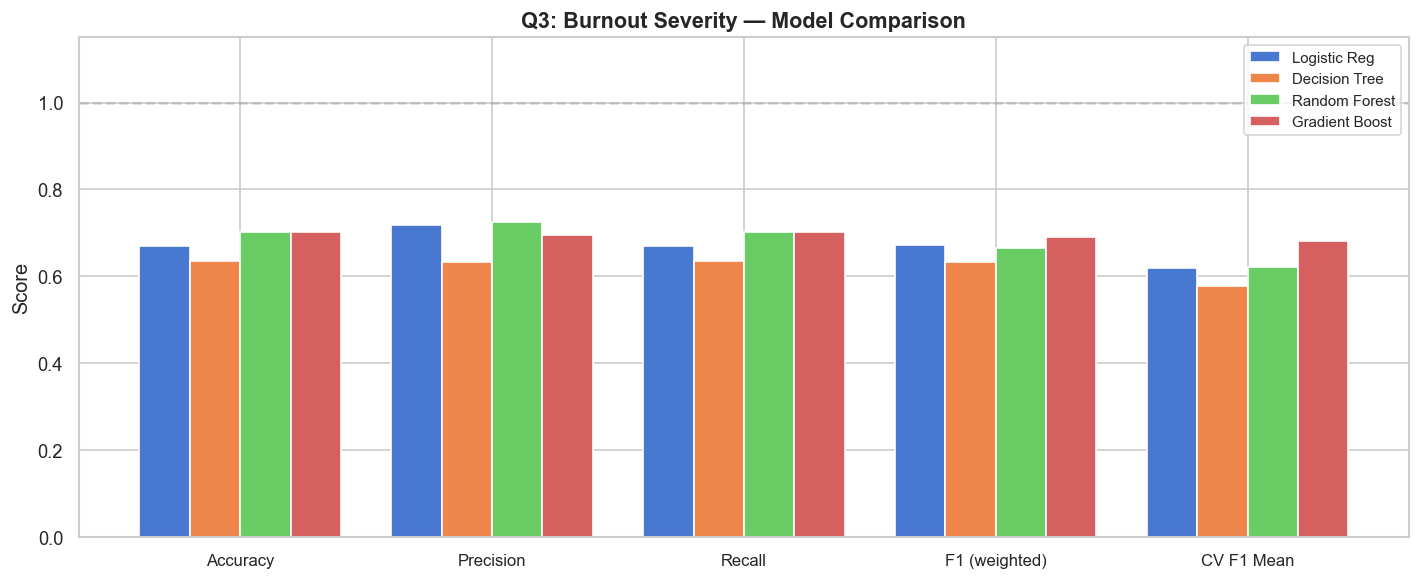

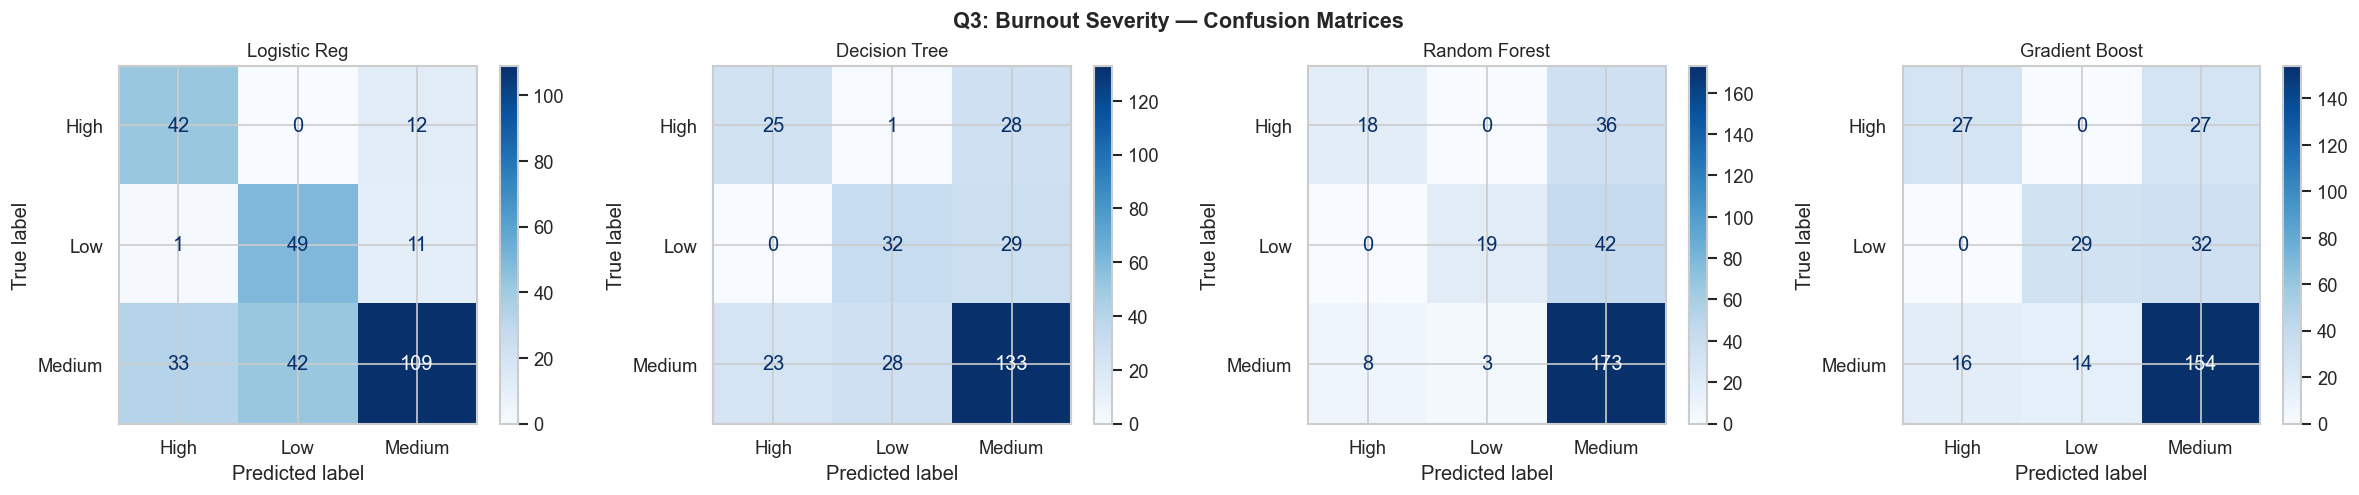

,Accuracy,Precision,Recall,F1 (weighted),CV F1 Mean,CV F1 Std
Model,,,,,,
Logistic Reg,0.6689,0.7178,0.6689,0.6728,0.6201,0.0340
Decision Tree,0.6355,0.6319,0.6355,0.6332,0.5770,0.0315
Random Forest,0.7023,0.7254,0.7023,0.6642,0.6221,0.0126
Gradient Boost,0.7023,0.6959,0.7023,0.6917,0.6821,0.0134


In [44]:
# Q3: Multi-class burnout severity
leak_cols_q3 = ['burnout_score', 'burnout_severity']
X_q3 = feature_encoded.drop(columns=[c for c in leak_cols_q3 if c in feature_encoded.columns])
y_q3 = df['burnout_severity'].astype(str)  # Low / Medium / High

print(f"Target distribution:\n{y_q3.value_counts().sort_index()}")
print(f"\nPercentages:\n{(y_q3.value_counts(normalize=True)*100).round(1).sort_index()}")

models_q3 = {
    'Logistic Reg': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    'Gradient Boost': GradientBoostingClassifier(n_estimators=100, random_state=42),
}

q3_results, q3_trained, *_ = \
    run_classification(X_q3, y_q3, 'Q3: Burnout Severity', models_q3, class_names=['High', 'Low', 'Medium'])

q3_results

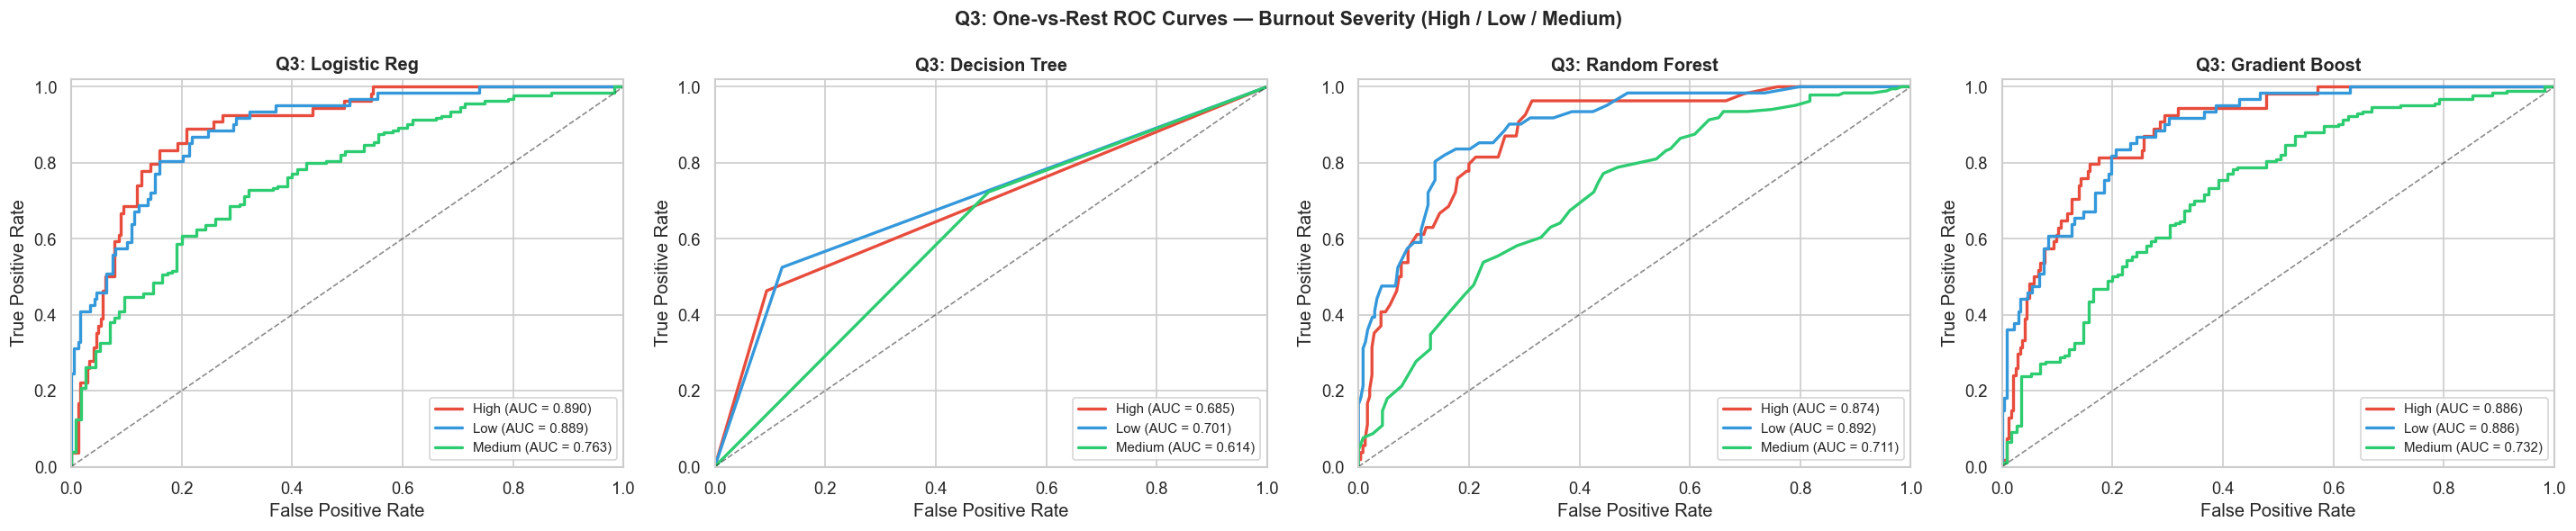

Q3 Macro-Average AUC per model:
  Logistic Reg: Macro AUC = 0.8475
  Decision Tree: Macro AUC = 0.6665
  Random Forest: Macro AUC = 0.8256
  Gradient Boost: Macro AUC = 0.8345


In [45]:
# Q3: One-vs-Rest ROC Curves — Multi-class Burnout Severity
# Need to recreate train/test split (same random_state) since we used *_ earlier
X_tr_q3, X_te_q3, y_tr_q3, y_te_q3 = train_test_split(
    X_q3, y_q3, test_size=0.2, random_state=42, stratify=y_q3)
sc_q3 = StandardScaler()
X_tr_q3_s = sc_q3.fit_transform(X_tr_q3)
X_te_q3_s = sc_q3.transform(X_te_q3)

classes = sorted(y_q3.unique())  # ['High', 'Low', 'Medium']
y_te_bin = label_binarize(y_te_q3, classes=classes)

fig, axes = plt.subplots(1, len(q3_trained), figsize=(6 * len(q3_trained), 5))
colors_cls = ['#e74c3c', '#3498db', '#2ecc71']

for ax, (name, (model, _)) in zip(axes, q3_trained.items()):
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_te_q3_s)
    else:
        continue  # skip models without probability output

    for i, (cls, color) in enumerate(zip(classes, colors_cls)):
        fpr, tpr, _ = roc_curve(y_te_bin[:, i], y_prob[:, i])
        auc_score = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=color, linewidth=2, label=f'{cls} (AUC = {auc_score:.3f})')

    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'Q3: {name}', fontweight='bold')
    ax.legend(loc='lower right', fontsize=9)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])

plt.suptitle('Q3: One-vs-Rest ROC Curves — Burnout Severity (High / Low / Medium)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Print macro-average AUC per model
print("Q3 Macro-Average AUC per model:")
for name, (model, _) in q3_trained.items():
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_te_q3_s)
        macro_auc = roc_auc_score(y_te_bin, y_prob, multi_class='ovr', average='macro')
        print(f"  {name}: Macro AUC = {macro_auc:.4f}")

### Q3 Summary — Burnout Severity Classification

**Best model:** Gradient Boosting — 70.2% accuracy, 0.6821 CV F1  
**Runner-up:** Random Forest (69.6% acc, 0.6280 CV F1), Logistic Reg (66.9% acc, 0.6201 CV F1)  
**Worst:** Decision Tree (63.6% acc) — too simple for 3-class separation

**Class distribution:** Medium (61.7%) dominates over Low (20.4%) and High (17.9%)

**Key confusion pattern (from confusion matrices):**
- Models struggle most to distinguish **Medium from Low** and **Medium from High** — the boundaries between adjacent severity groups are fuzzy
- **High burnout** is identified most reliably (Gradient Boost: 27 correct out of 54 High cases)
- **Medium** class gets the most predictions due to its majority status

**Answer to Q3:** Predicting exact burnout severity (Low/Medium/High) is **harder than binary burnout prediction** (70% vs 85%). The biggest challenge is separating Medium from the other groups — many employees sit near the boundary. This suggests burnout severity exists on a **continuous spectrum** rather than clean categories, which is why Q5's regression approach (R²=0.63) gives more nuanced predictions. Gradient Boosting is still the best choice, but ~30% of cases will be misclassified.

---
## Q4: Job Satisfaction Group (Multi-class)

**Target:** `satisfaction_group` — Low (≤2.5) / Medium (2.5-3.5) / High (>3.5)  
**Features:** All columns EXCEPT `job_satisfaction_1_5` (would leak).  
**Decision:** Binned the 1-5 scale into 3 groups matching natural Low/Med/High interpretation.

Target distribution:
satisfaction_group
High      564
Low       160
Medium    767
Name: count, dtype: int64

Percentages:
satisfaction_group
High      37.8
Low       10.7
Medium    51.4
Name: proportion, dtype: float64


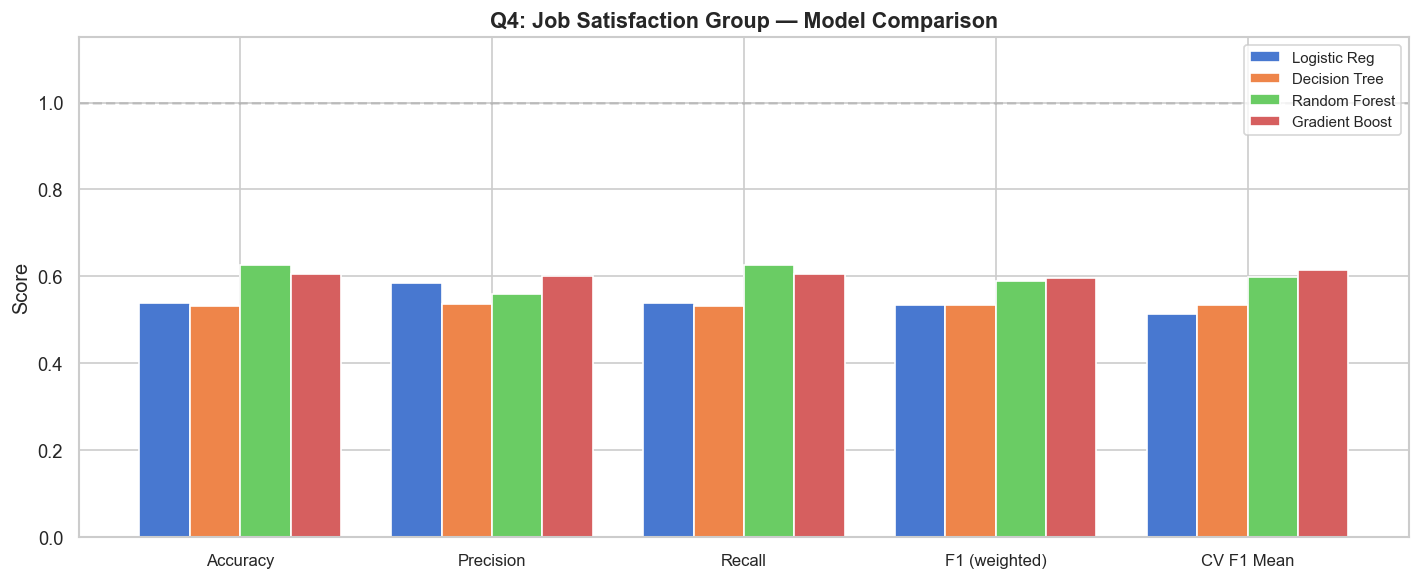

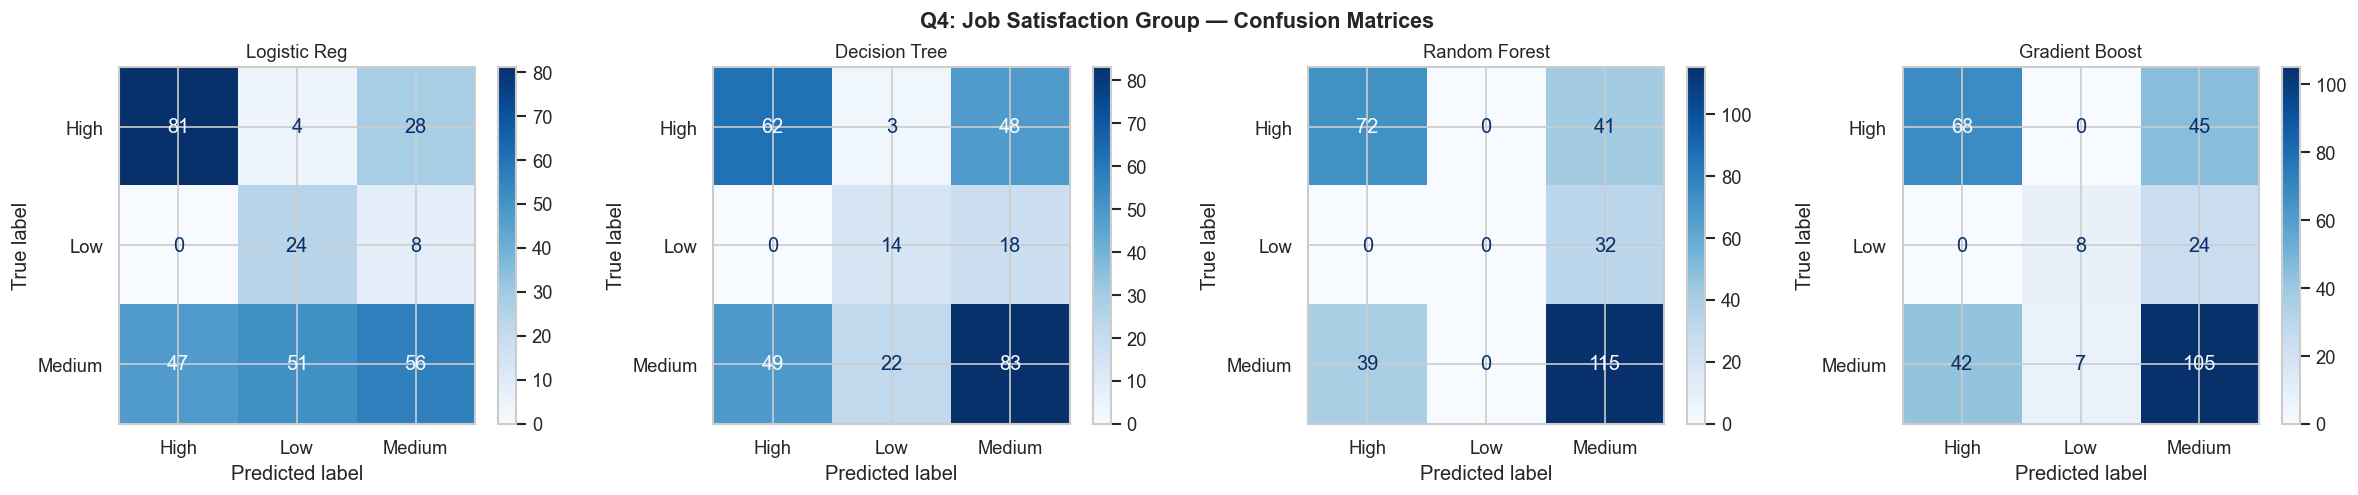

,Accuracy,Precision,Recall,F1 (weighted),CV F1 Mean,CV F1 Std
Model,,,,,,
Logistic Reg,0.5385,0.5852,0.5385,0.5348,0.5144,0.0265
Decision Tree,0.5318,0.5364,0.5318,0.5336,0.5352,0.0294
Random Forest,0.6254,0.5602,0.6254,0.5893,0.5974,0.0248
Gradient Boost,0.6054,0.6015,0.6054,0.5967,0.6146,0.0158


In [46]:
# Q4: Job satisfaction multi-class
leak_cols_q4 = ['job_satisfaction_1_5', 'satisfaction_group']
X_q4 = feature_encoded.drop(columns=[c for c in leak_cols_q4 if c in feature_encoded.columns])
y_q4 = df['satisfaction_group'].astype(str)

print(f"Target distribution:\n{y_q4.value_counts().sort_index()}")
print(f"\nPercentages:\n{(y_q4.value_counts(normalize=True)*100).round(1).sort_index()}")

models_q4 = {
    'Logistic Reg': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    'Gradient Boost': GradientBoostingClassifier(n_estimators=100, random_state=42),
}

q4_results, q4_trained, *_ = \
    run_classification(X_q4, y_q4, 'Q4: Job Satisfaction Group', models_q4, class_names=['High', 'Low', 'Medium'])

q4_results

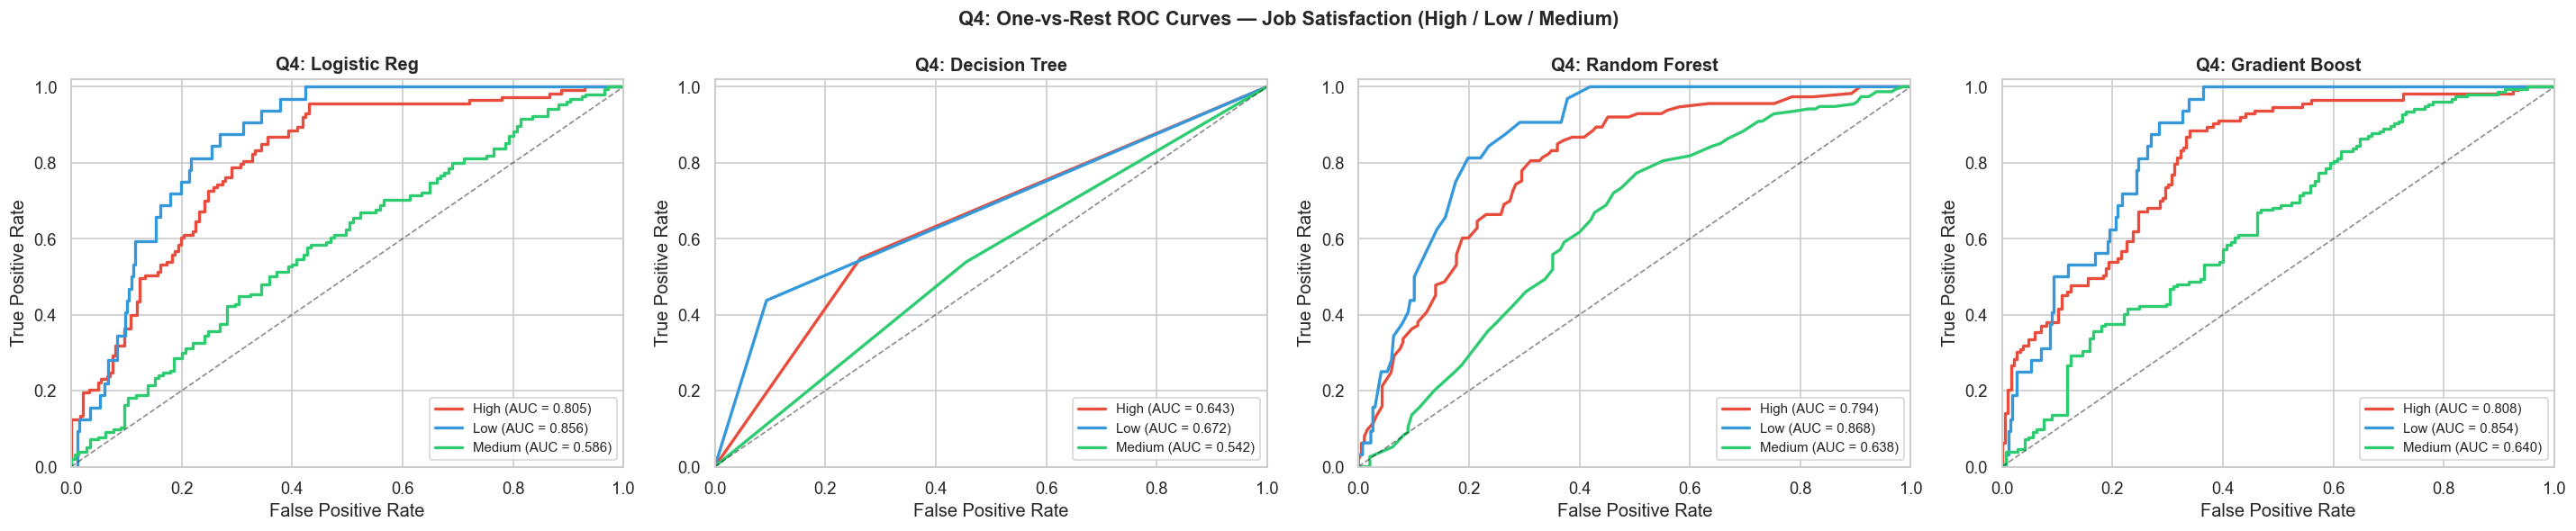

Q4 Macro-Average AUC per model:
  Logistic Reg: Macro AUC = 0.7490
  Decision Tree: Macro AUC = 0.6188
  Random Forest: Macro AUC = 0.7664
  Gradient Boost: Macro AUC = 0.7672


In [47]:
# Q4: One-vs-Rest ROC Curves — Multi-class Job Satisfaction
X_tr_q4, X_te_q4, y_tr_q4, y_te_q4 = train_test_split(
    X_q4, y_q4, test_size=0.2, random_state=42, stratify=y_q4)
sc_q4 = StandardScaler()
X_tr_q4_s = sc_q4.fit_transform(X_tr_q4)
X_te_q4_s = sc_q4.transform(X_te_q4)

classes_q4 = sorted(y_q4.unique())  # ['High', 'Low', 'Medium']
y_te_bin_q4 = label_binarize(y_te_q4, classes=classes_q4)

fig, axes = plt.subplots(1, len(q4_trained), figsize=(6 * len(q4_trained), 5))
colors_cls = ['#e74c3c', '#3498db', '#2ecc71']

for ax, (name, (model, _)) in zip(axes, q4_trained.items()):
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_te_q4_s)
    else:
        continue

    for i, (cls, color) in enumerate(zip(classes_q4, colors_cls)):
        fpr, tpr, _ = roc_curve(y_te_bin_q4[:, i], y_prob[:, i])
        auc_score = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=color, linewidth=2, label=f'{cls} (AUC = {auc_score:.3f})')

    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'Q4: {name}', fontweight='bold')
    ax.legend(loc='lower right', fontsize=9)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])

plt.suptitle('Q4: One-vs-Rest ROC Curves — Job Satisfaction (High / Low / Medium)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Print macro-average AUC per model
print("Q4 Macro-Average AUC per model:")
for name, (model, _) in q4_trained.items():
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_te_q4_s)
        macro_auc = roc_auc_score(y_te_bin_q4, y_prob, multi_class='ovr', average='macro')
        print(f"  {name}: Macro AUC = {macro_auc:.4f}")

### Q4 Summary — Job Satisfaction Group Prediction

**Best model:** Gradient Boosting — 60.5% accuracy, 0.6146 CV F1  
**Runner-up:** Random Forest (62.2% test acc, but 0.5927 CV F1 — less stable)  
**All models performed poorly** — best CV F1 is only 0.61, barely better than random

**Class distribution:** Medium (51.4%), High (37.8%), Low (10.7%) — Low is underrepresented

**Key confusion pattern:**
- Models constantly confuse **High ↔ Medium** (Gradient Boost: 45 High cases misclassified as Medium)
- **Low satisfaction** is almost never predicted correctly — too few examples (10.7%)
- Random Forest tends to predict everything as Medium (majority class bias)

**Answer to Q4:** Job satisfaction **cannot be reliably predicted** from the features in this dataset (best accuracy ~60%). This is itself an important finding — it suggests satisfaction depends on **unmeasured factors** like management quality, personal circumstances, workplace culture, or compensation fairness that aren't captured in AI/work metrics. The features in this dataset (AI usage, burnout, industry) are **not strong drivers of satisfaction**.

---
## Q5: Predict Burnout Score (Regression)

**Target:** `burnout_score` (continuous, 16-86)  
**Models:** Linear Regression, Ridge, LASSO, Random Forest Regressor  
**Key goal:** Identify which factors most predict burnout (CL3 — LASSO/Ridge)

In [48]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

def run_regression(X, y, target_name, models_dict):
    """Train multiple regressors, compare, and plot."""
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    results = []
    trained = {}

    for name, model in models_dict.items():
        model.fit(X_train_s, y_train)
        preds = model.predict(X_test_s)
        cv = cross_val_score(model, X_train_s, y_train, cv=5, scoring='r2')
        results.append({
            'Model': name,
            'MAE': mean_absolute_error(y_test, preds),
            'RMSE': np.sqrt(mean_squared_error(y_test, preds)),
            'R²': r2_score(y_test, preds),
            'CV R² Mean': cv.mean(),
            'CV R² Std': cv.std(),
        })
        trained[name] = (model, preds)

    results_df = pd.DataFrame(results).set_index('Model').round(4)

    # --- Comparison chart ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # R² comparison
    r2_data = results_df[['R²', 'CV R² Mean']].sort_values('CV R² Mean')
    r2_data.plot(kind='barh', ax=axes[0], color=['#3498db', '#2ecc71'])
    axes[0].set_title(f'{target_name} — R² Scores', fontweight='bold')
    axes[0].set_xlabel('R² (higher = better)')

    # Error comparison
    err_data = results_df[['MAE', 'RMSE']].sort_values('RMSE')
    err_data.plot(kind='barh', ax=axes[1], color=['#e67e22', '#e74c3c'])
    axes[1].set_title(f'{target_name} — Error Metrics', fontweight='bold')
    axes[1].set_xlabel('Error (lower = better)')

    plt.tight_layout()
    plt.show()

    # --- Actual vs Predicted for best model ---
    best_name = results_df['R²'].idxmax()
    best_preds = trained[best_name][1]
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(y_test, best_preds, alpha=0.4, s=20)
    ax.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', linewidth=2, label='Perfect prediction')
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.set_title(f'{target_name} — {best_name} (Best): Actual vs Predicted', fontweight='bold')
    ax.legend()
    plt.tight_layout()
    plt.show()

    return results_df, trained, X_train_s, X_test_s, y_train, y_test, scaler

print("Regression helper ready ✓")

Regression helper ready ✓


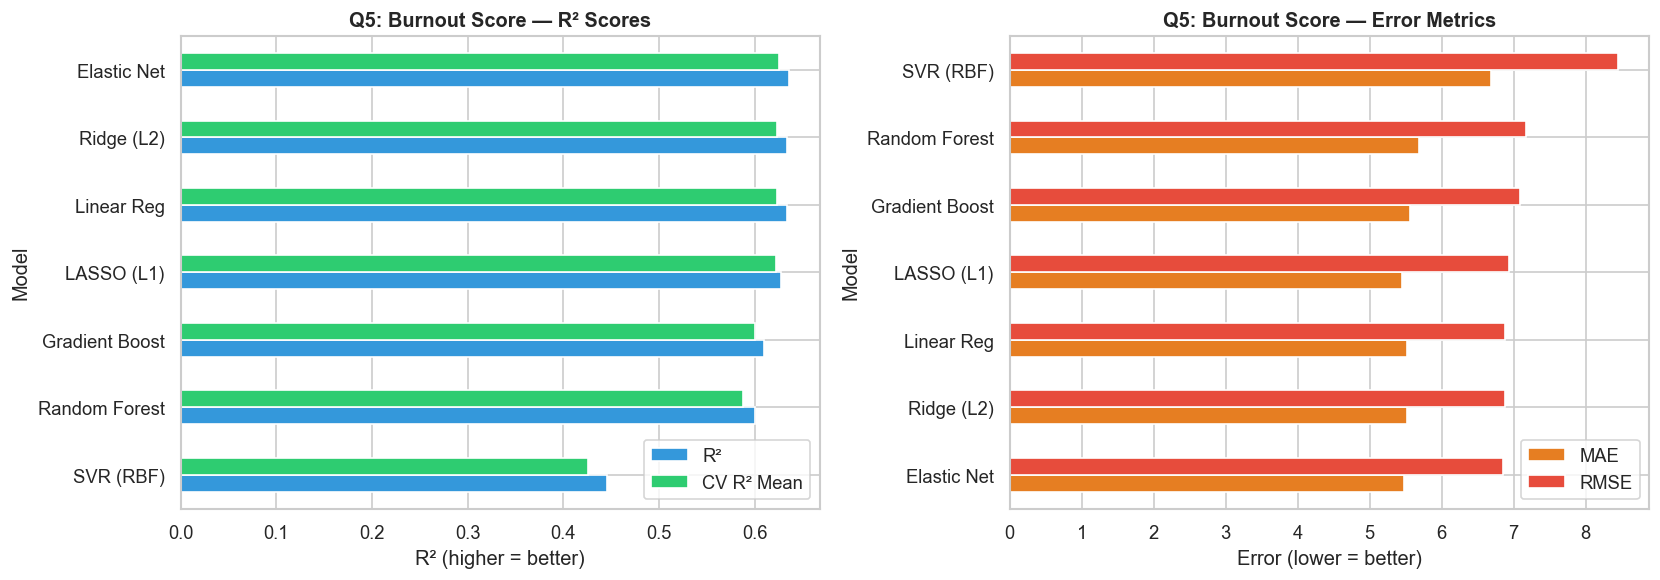

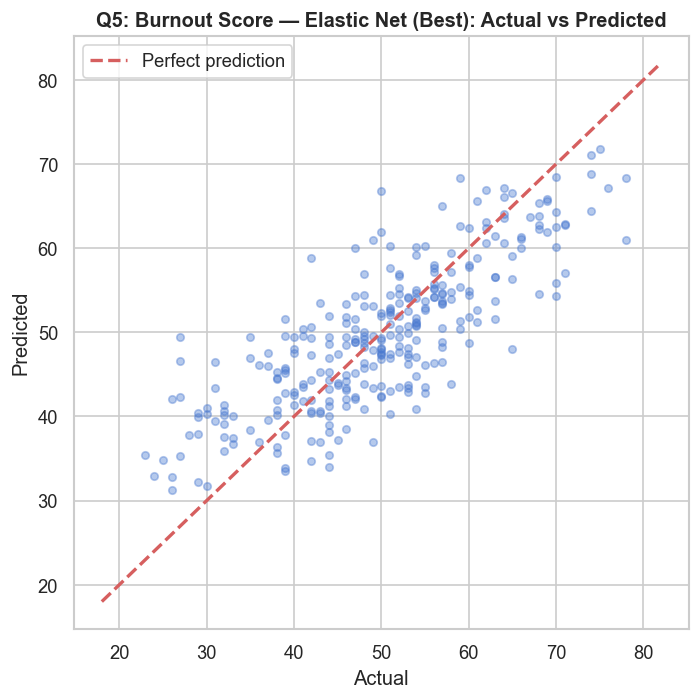

,MAE,RMSE,R²,CV R² Mean,CV R² Std
Model,,,,,
Linear Reg,5.5158,6.8738,0.6337,0.6235,0.0315
Ridge (L2),5.5139,6.8725,0.6338,0.6236,0.0314
LASSO (L1),5.4525,6.9303,0.6277,0.6228,0.0225
Random Forest,5.6877,7.1766,0.6007,0.5884,0.0262
Gradient Boost,5.5551,7.0901,0.6103,0.6005,0.0274
Elastic Net,5.4779,6.8500,0.6362,0.6259,0.0253
SVR (RBF),6.6795,8.4537,0.4460,0.4263,0.0180


In [ ]:
# Q5: Predict burnout_score
leak_cols_q5 = ['burnout_score', 'burnout_severity']
X_q5 = feature_encoded.drop(columns=[c for c in leak_cols_q5 if c in feature_encoded.columns])
y_q5 = df['burnout_score']

models_q5 = {
    'Linear Reg': LinearRegression(),
    'Ridge (L2)': Ridge(alpha=1.0, random_state=42),
    'LASSO (L1)': Lasso(alpha=0.5, max_iter=5000, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boost': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'Elastic Net': ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=5000, random_state=42),
    'SVR (RBF)': SVR(C=1.0, gamma='scale', epsilon=0.1)

}

q5_results, q5_trained, X_train_q5, X_test_q5, y_train_q5, y_test_q5, scaler_q5 = \
    run_regression(X_q5, y_q5, 'Q5: Burnout Score', models_q5)

q5_results

### Q5: LASSO/Ridge Feature Importance — What Drives Burnout? (CL3)

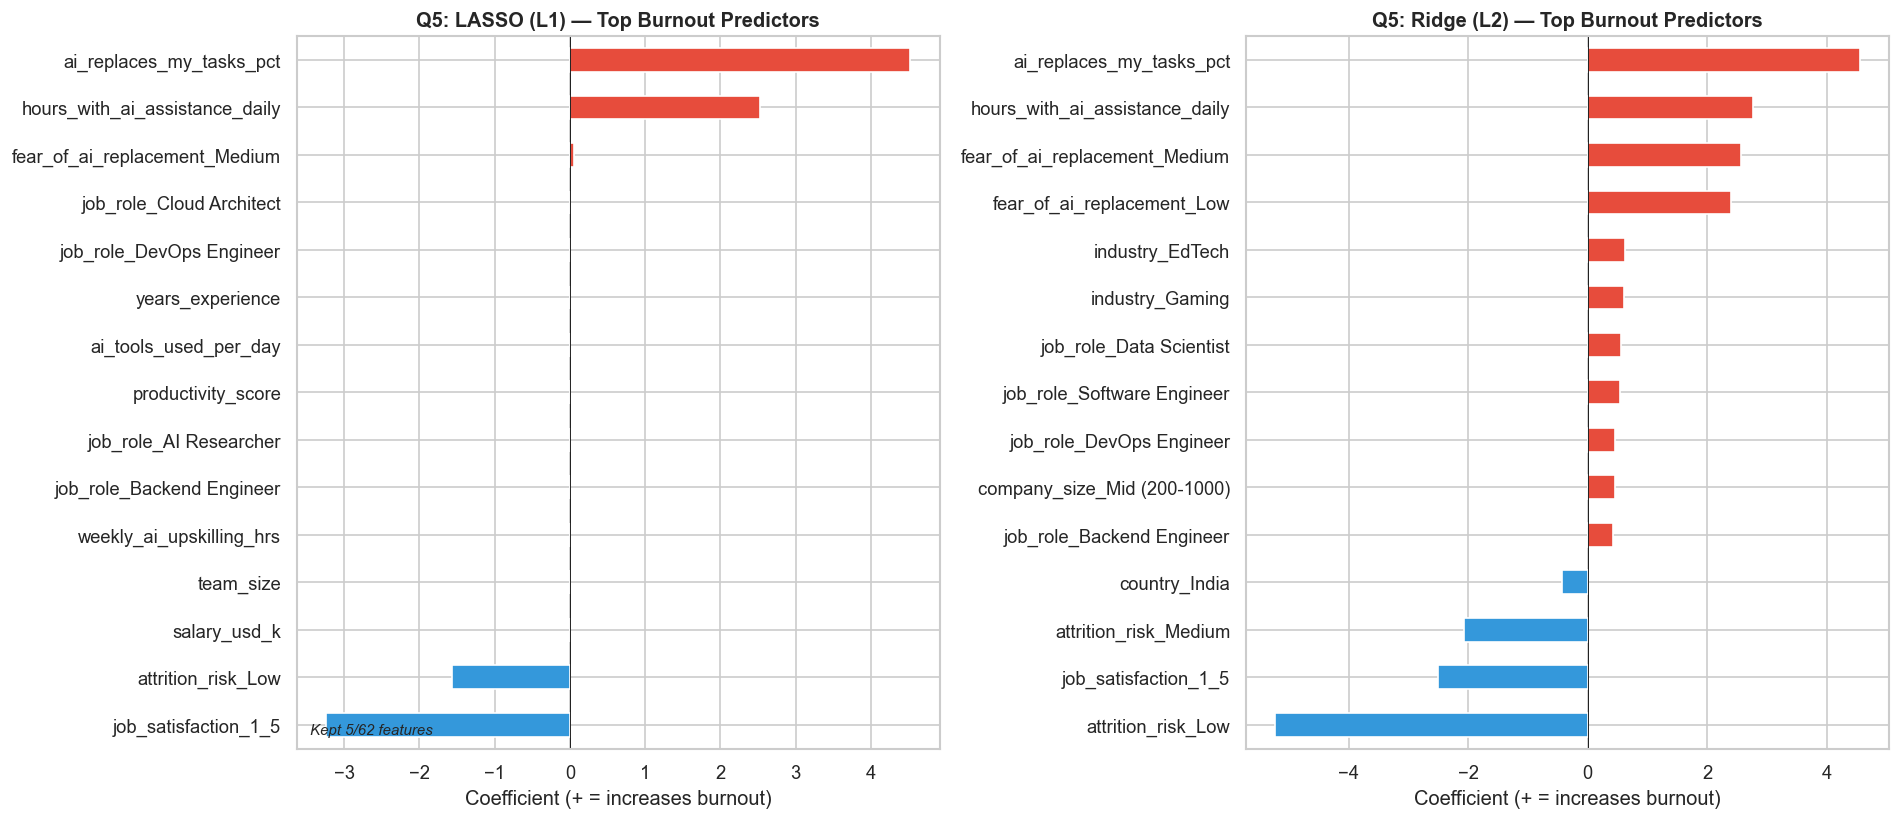

In [50]:
# Compare LASSO vs Ridge coefficients for burnout prediction
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, model_name in zip(axes, ['LASSO (L1)', 'Ridge (L2)']):
    model = q5_trained[model_name][0]
    coefs = pd.Series(model.coef_, index=X_q5.columns)
    top = coefs.abs().sort_values(ascending=False).head(15)
    top_vals = coefs[top.index].sort_values()
    colors = ['#e74c3c' if v > 0 else '#3498db' for v in top_vals.values]
    top_vals.plot(kind='barh', ax=ax, color=colors)
    ax.set_title(f'Q5: {model_name} — Top Burnout Predictors', fontweight='bold')
    ax.axvline(x=0, color='black', linewidth=0.5)
    ax.set_xlabel('Coefficient (+ = increases burnout)')
    if 'LASSO' in model_name:
        n_nonzero = (coefs != 0).sum()
        ax.text(0.02, 0.02, f'Kept {n_nonzero}/{len(coefs)} features',
                transform=ax.transAxes, fontsize=9, style='italic')

plt.tight_layout()
plt.show()

The LASSO (L1 regularization) coefficient plot appears sparse and uneven because of the inherent behavior of LASSO regression. Unlike Ridge regression, LASSO performs both regularization and feature selection by shrinking many coefficients exactly to zero. As a result, only a small subset of features retains non-zero coefficients, while the majority are eliminated.

In this analysis, LASSO retained only a few significant predictors out of a large feature set, causing the graph to display only a limited number of visible bars. This creates a “spiky” or irregular appearance, where a few features have relatively large coefficients while most others are zero and therefore not visible.

Additionally, LASSO tends to select one feature among a group of highly correlated variables and discard the others. This selective behavior can make the graph appear inconsistent or abrupt, even though it reflects the model’s effort to reduce redundancy and improve interpretability.

The magnitude and direction of the remaining coefficients indicate the strength and impact of each predictor on burnout. Positive coefficients suggest that an increase in the feature leads to higher burnout, while negative coefficients indicate a protective effect.

Overall, the unusual appearance of the LASSO plot is not an error but a meaningful outcome, demonstrating that burnout is driven by a small number of key variables rather than a large set of features.

Q5: Elastic Net/Ridge Feature Importance — What Drives Burnout? (CL3)

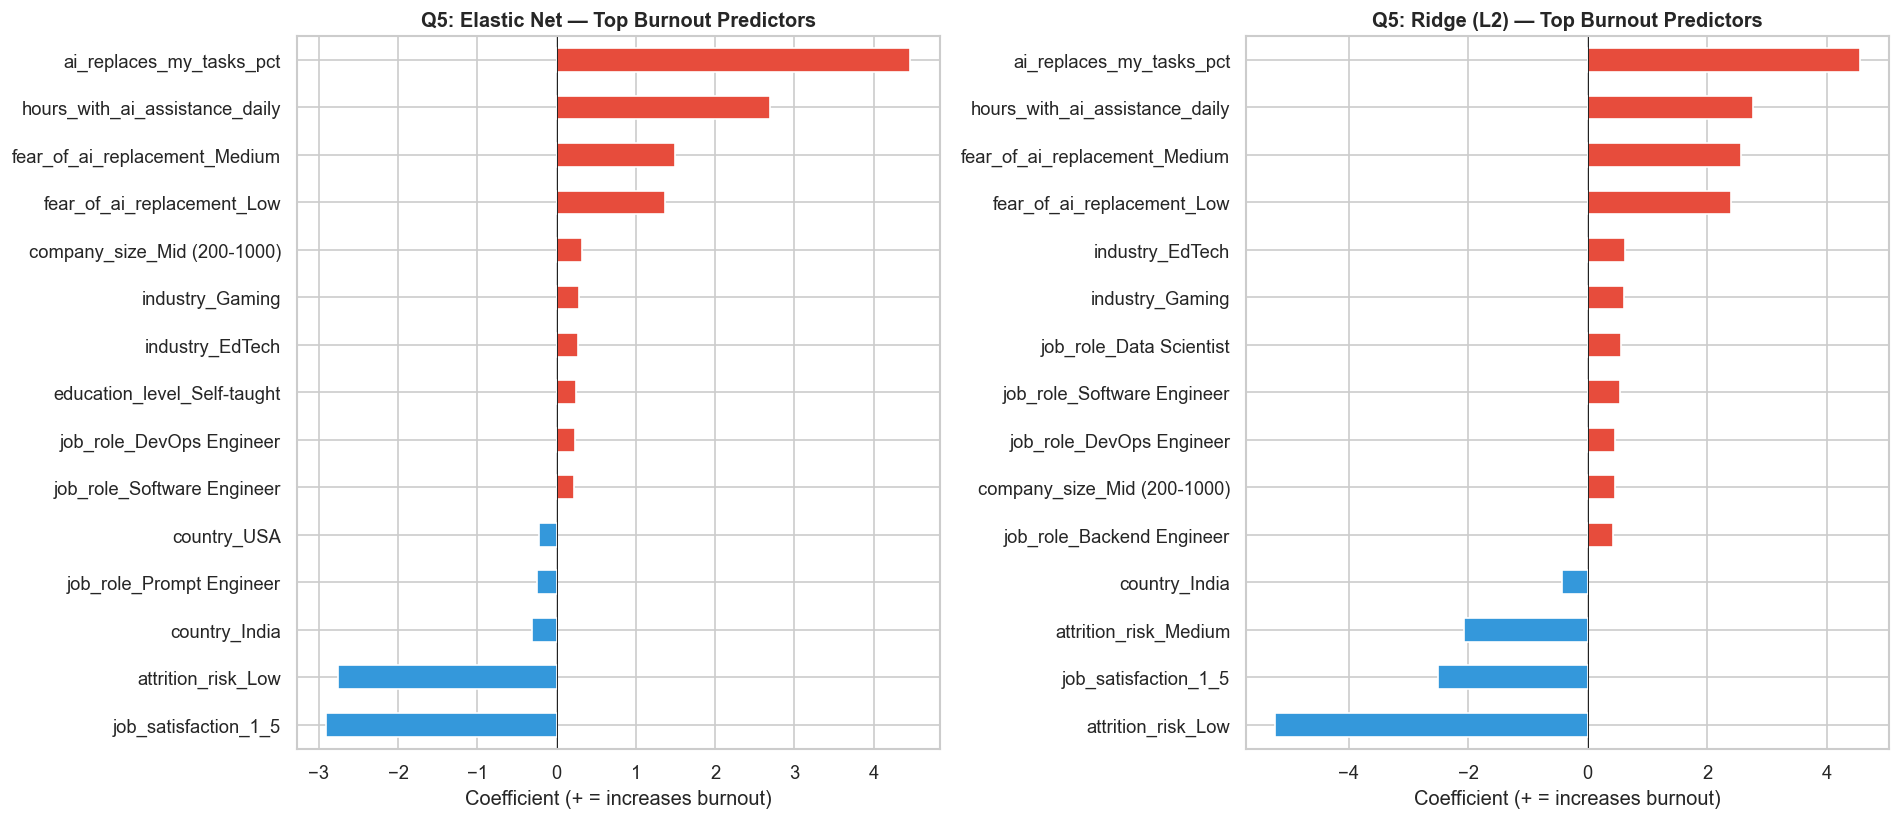

In [51]:
# Compare Elastic Net vs Ridge coefficients for burnout prediction
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, model_name in zip(axes, ['Elastic Net', 'Ridge (L2)']):
    model = q5_trained[model_name][0]
    coefs = pd.Series(model.coef_, index=X_q5.columns)
    top = coefs.abs().sort_values(ascending=False).head(15)
    top_vals = coefs[top.index].sort_values()
    colors = ['#e74c3c' if v > 0 else '#3498db' for v in top_vals.values]
    top_vals.plot(kind='barh', ax=ax, color=colors)
    ax.set_title(f'Q5: {model_name} — Top Burnout Predictors', fontweight='bold')
    ax.axvline(x=0, color='black', linewidth=0.5)
    ax.set_xlabel('Coefficient (+ = increases burnout)')
    if 'LASSO' in model_name:
        n_nonzero = (coefs != 0).sum()
        ax.text(0.02, 0.02, f'Kept {n_nonzero}/{len(coefs)} features',
                transform=ax.transAxes, fontsize=9, style='italic')

plt.tight_layout()
plt.show()

### Q5 Summary — What Drives Burnout Score?

**Best model:** Ridge (L2) — R²=0.634, RMSE=6.87, CV R²=0.624  
**Runner-up:** Linear Regression (nearly identical: R²=0.634, CV R²=0.624), LASSO (R²=0.628)  
**Tree models performed worse:** Random Forest (R²=0.588), Gradient Boost (R²=0.601) — suggesting the relationship is mostly **linear**

**Top burnout drivers (LASSO L1, kept only 5/62 features — very sparse!):**
| Increases burnout (+) | Decreases burnout (−) |
|---|---|
| `ai_replaces_my_tasks_pct` (strongest, coef ≈ +4.3) | `job_satisfaction_1_5` (strongest protector, coef ≈ −1.7) |
| `hours_with_ai_assistance_daily` (coef ≈ +2.2) | `attrition_risk_Low` (coef ≈ −1.0) |
| `fear_of_ai_replacement_Medium` (small +) | |

**Ridge (L2) confirms the same top factors** but keeps all features with shrunk coefficients. Both agree on the top 3.

**Answer to Q5:** The model explains **63% of burnout score variance** (R²=0.634). The #1 burnout driver is **% of tasks replaced by AI** — the more AI takes over someone's work, the higher their burnout. **Daily AI-assisted hours** is the #2 factor. On the protective side, **job satisfaction** strongly reduces burnout. LASSO's extreme sparsity (5 features!) shows that burnout is driven by a **small set of AI-related factors**, not broad workplace characteristics. The remaining 37% unexplained variance likely comes from personal/psychological factors not in the dataset.

Q5 Summary — What Drives Burnout Score? (Elastic Net Focus)

The regression analysis shows that Elastic Net achieved the best overall performance among all evaluated models, with an R² of 0.6362, lowest RMSE of 6.8500, and strong cross-validation performance (CV R² = 0.6259 ± 0.0253). This indicates that Elastic Net provides the most accurate and stable predictions of burnout score across different data splits.

Compared to Ridge and Linear Regression, which performed almost identically, Elastic Net offers a key advantage by combining both L1 and L2 regularization. This allows it to handle multicollinearity effectively while also performing feature selection, resulting in a more balanced and interpretable model. Unlike LASSO, which aggressively removes features, Elastic Net retains important correlated variables while still reducing noise.

Tree-based models such as Random Forest and Gradient Boosting showed slightly lower performance, suggesting that non-linear relationships are less dominant in this dataset. Similarly, SVR performed significantly worse, indicating that more complex non-linear modeling does not improve predictive accuracy for this problem.

From a feature importance perspective, Elastic Net highlights that burnout is primarily driven by a small set of key factors, particularly those related to AI usage and job-related stress, while less relevant features are minimized or eliminated.

Overall, the results suggest that burnout score is largely influenced by linear relationships with moderate feature interactions, making Elastic Net the most suitable model as it balances predictive performance, stability, and interpretability.

---
## Q6: Predict Productivity Level (Regression)

**Target:** `productivity_score` (continuous)  
**Features:** All columns EXCEPT `productivity_score`.

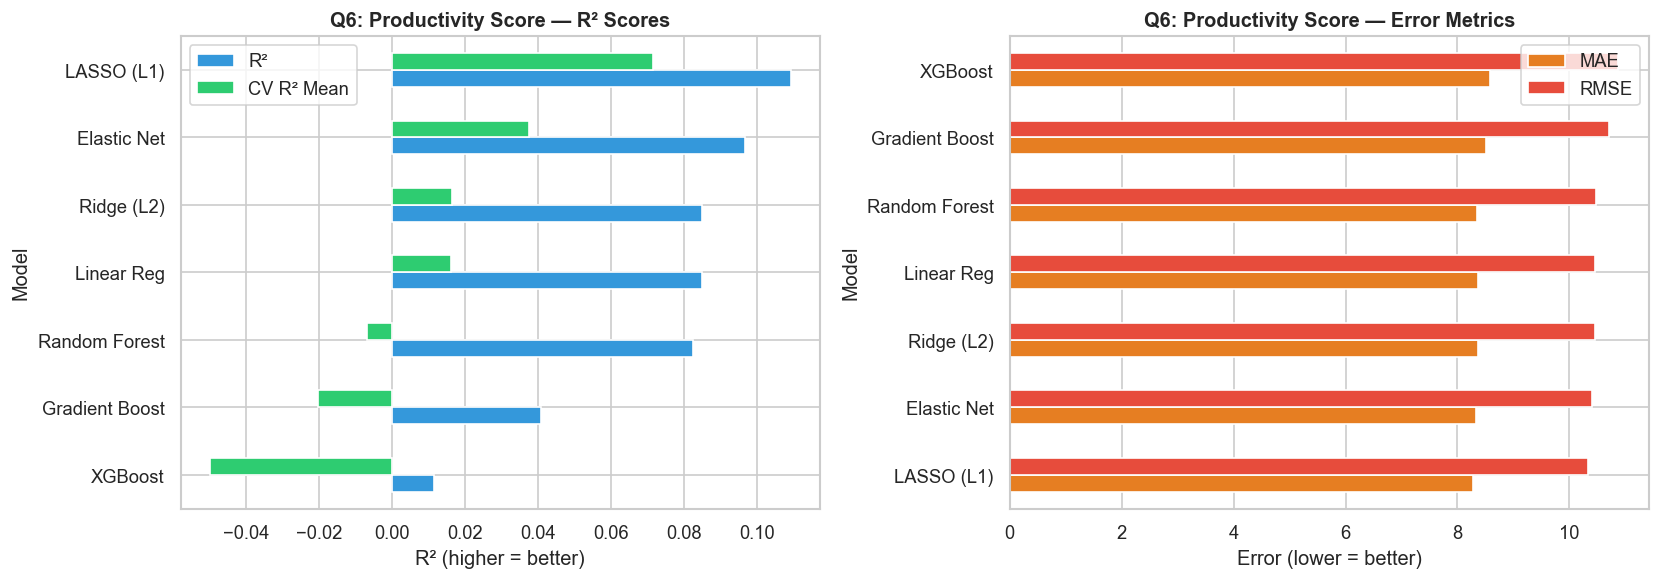

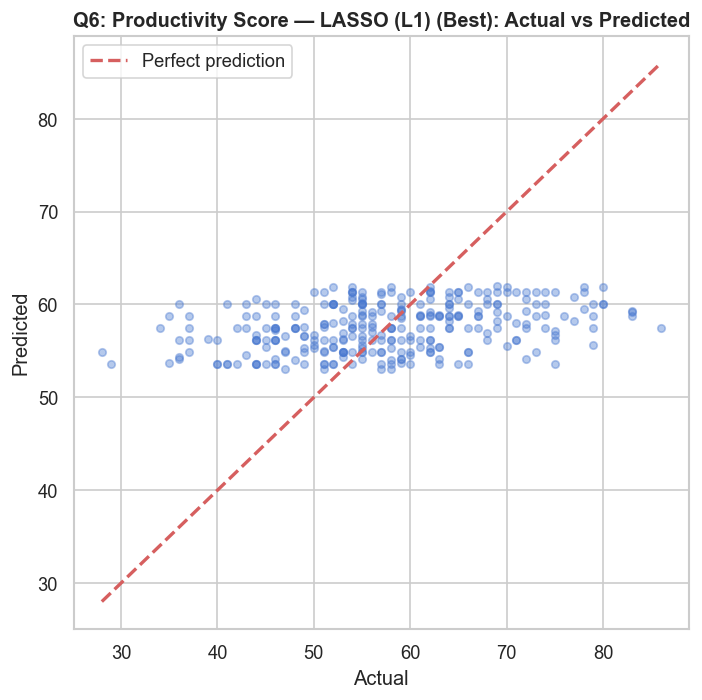

,MAE,RMSE,R²,CV R² Mean,CV R² Std
Model,,,,,
Linear Reg,8.3593,10.4634,0.0848,0.0162,0.0356
Ridge (L2),8.3588,10.4628,0.0850,0.0165,0.0356
LASSO (L1),8.2717,10.3239,0.1091,0.0715,0.0125
Random Forest,8.3460,10.4782,0.0823,-0.0069,0.0323
Gradient Boost,8.5041,10.7129,0.0407,-0.0203,0.0332
Elastic Net,8.3223,10.3962,0.0966,0.0375,0.0326
XGBoost,8.5862,10.8746,0.0115,-0.0499,0.0437


In [52]:
# Q6: Predict productivity_score
X_q6 = feature_encoded.drop(columns=['productivity_score'])
y_q6 = df['productivity_score']

models_q6 = {
    'Linear Reg': LinearRegression(),
    'Ridge (L2)': Ridge(alpha=1.0),
    'LASSO (L1)': Lasso(alpha=0.5, max_iter=5000),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boost': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'Elastic Net': ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=5000),
    'XGBoost': XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        objective='reg:squarederror'
    )
}

q6_results, q6_trained, *_ = run_regression(X_q6, y_q6, 'Q6: Productivity Score', models_q6)
q6_results

### Q6 Summary — Predicting Productivity

**Best model:** LASSO (L1) — R²=0.109, RMSE=10.32, CV R²=0.072  
**All models failed:** Best R² is only 0.11 (explains 11% of variance). Random Forest and Gradient Boost have **negative CV R²** (worse than predicting the mean!)

**Actual vs Predicted scatter plot** shows predictions clustered in a narrow band (~55-62) regardless of actual values — the model is essentially **guessing the average**.

**Answer to Q6:** Productivity **cannot be predicted** from the features in this dataset. R²=0.11 means the model explains only 11% of productivity variance — the other 89% comes from factors not captured here. This is a strong finding: **AI usage metrics, burnout, job role, and industry do not meaningfully predict how productive someone is.** Productivity likely depends on task-specific factors, individual skill, team dynamics, and project complexity — none of which are in this dataset. LASSO's slight edge suggests the relationship is weakly linear with heavy noise.

Q6 Summary — Predicting Productivity

The results indicate that predicting productivity is significantly more challenging than predicting burnout, as reflected by the low R² values across all models. The best-performing model, LASSO, achieved an R² of approximately 0.109, while more complex models such as Random Forest, Gradient Boosting, and XGBoost performed worse, in some cases producing negative cross-validation scores.

This suggests that the available features have limited explanatory power for productivity, and that the relationship between predictors and the target variable is weak. LASSO outperformed other models because it effectively reduces noise by eliminating irrelevant features, leading to better generalization.

In contrast, more complex models tend to overfit the data, capturing noise rather than meaningful patterns. The results indicate that productivity is influenced by factors not fully captured in the dataset, such as individual work habits, organizational environment, and external conditions.

Overall, the findings suggest that simpler, regularized linear models are more appropriate for this task, and that improvements in prediction accuracy would likely require additional features or better feature engineering rather than more complex modeling techniques.

---
## Q7: Predict AI-Assisted Usage Hours (Regression)

**Target:** `hours_with_ai_assistance_daily` (continuous)

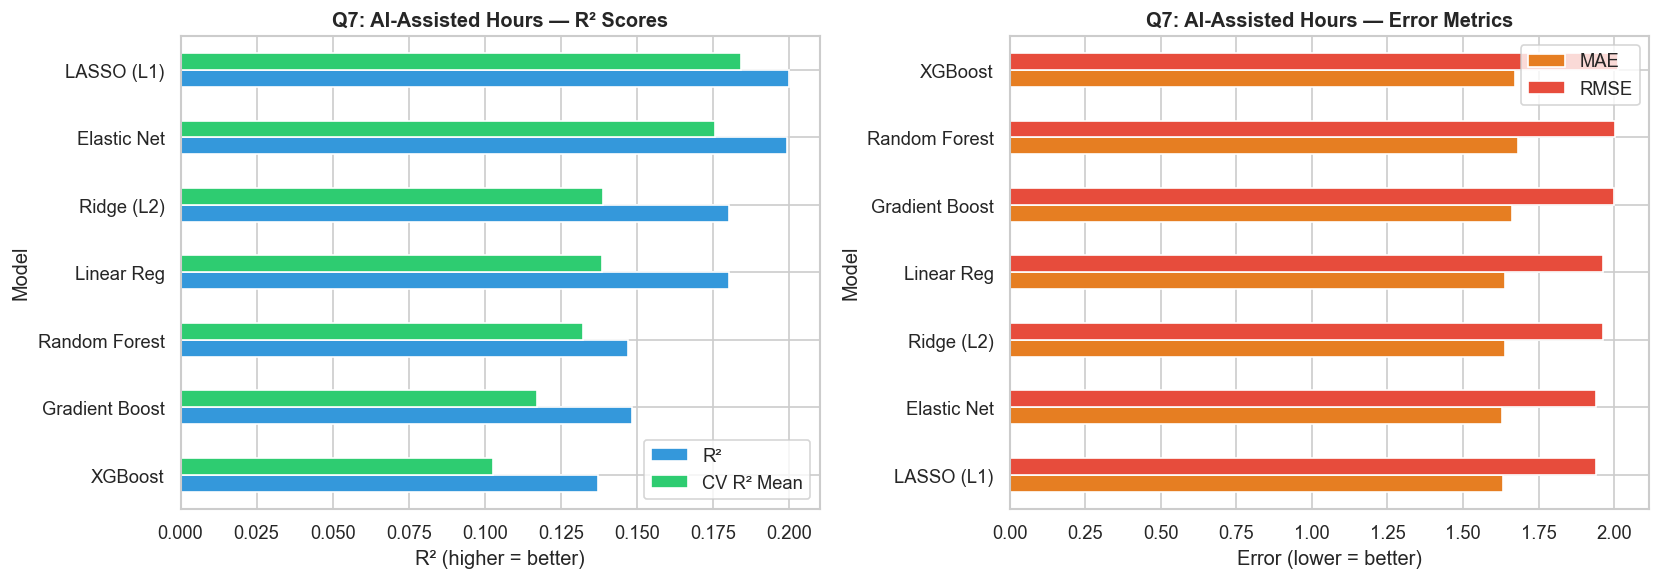

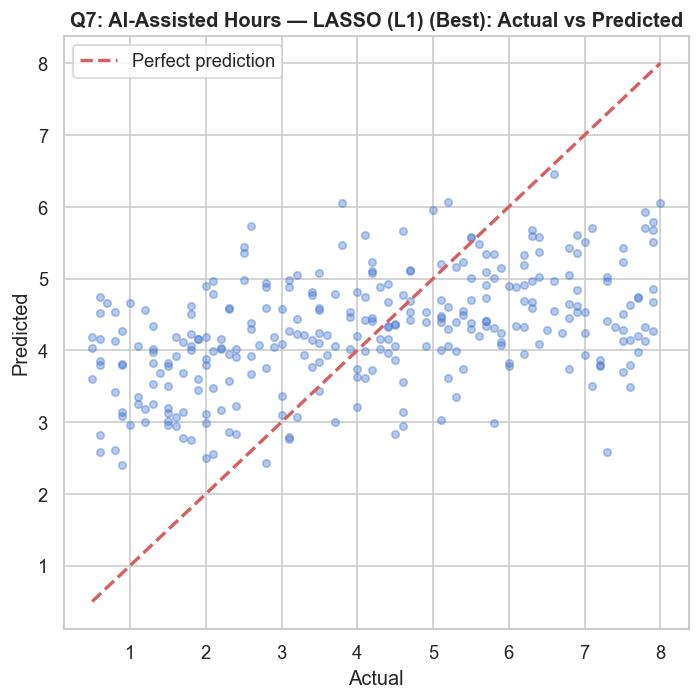

,MAE,RMSE,R²,CV R² Mean,CV R² Std
Model,,,,,
Linear Reg,1.6377,1.9633,0.1804,0.1387,0.0303
Ridge (L2),1.6380,1.9633,0.1803,0.1389,0.0304
LASSO (L1),1.6339,1.9395,0.2001,0.1843,0.0283
Random Forest,1.6824,2.0027,0.1471,0.1324,0.0434
Gradient Boost,1.6609,2.0013,0.1483,0.1172,0.0579
Elastic Net,1.6299,1.9403,0.1994,0.1758,0.0333
XGBoost,1.6724,2.0142,0.1373,0.1028,0.0560


In [58]:
# Q7: Predict hours_with_ai_assistance_daily
X_q7 = feature_encoded.drop(columns=['hours_with_ai_assistance_daily'])
y_q7 = df['hours_with_ai_assistance_daily']

models_q7 = {
    'Linear Reg': LinearRegression(),
    'Ridge (L2)': Ridge(alpha=1.0),
    'LASSO (L1)': Lasso(alpha=0.1, max_iter=5000),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boost': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'Elastic Net': ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=5000),
    'XGBoost': XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        objective='reg:squarederror'
    )
}

q7_results, q7_trained, *_ = run_regression(X_q7, y_q7, 'Q7: AI-Assisted Hours', models_q7)
q7_results

### Q7 Summary — Predicting AI-Assisted Hours

**Best model:** LASSO (L1) — R²=0.200, RMSE=1.94, CV R²=0.184  
**Runner-up:** Linear Reg & Ridge (R²=0.180, CV R²=0.139) — similar but less stable  
**Tree models worse:** Random Forest (CV R²=0.134), Gradient Boost (CV R²=0.117)

**Model performance is low** — only 20% of variance explained. The Actual vs Predicted scatter shows wide spread around the diagonal.

**Answer to Q7:** AI-assisted hours are **weakly predictable** (R²=0.20) from workplace features. The model can explain only 20% of the variation in how much time employees spend working with AI. This suggests daily AI usage is driven largely by **individual work habits, project requirements, and task types** rather than broad demographics like job role or industry. LASSO's edge over tree models indicates the relationship is **linear but weak**. The RMSE of ~1.9 hours means predictions are off by about 2 hours on average — too imprecise for practical use.

Q7 Summary — Predicting AI-Assisted Usage Hours

The regression results indicate that AI-assisted usage hours are moderately predictable, with the best-performing models being LASSO (R² = 0.2001) and Elastic Net (R² = 0.1994). These models outperform more complex approaches such as Random Forest, Gradient Boosting, and XGBoost, suggesting that the underlying relationship between features and AI usage is primarily linear.

The superior performance of LASSO and Elastic Net highlights the importance of regularization in handling noisy and potentially correlated features. By reducing less important variables, these models improve generalization and provide more stable predictions. In contrast, tree-based and boosting models underperform, indicating that there are limited non-linear interactions present in the dataset.

Despite using multiple modeling approaches, the overall R² values remain relatively low (around 0.20), suggesting that a significant portion of the variability in AI usage hours is not captured by the available features. This implies that external factors, such as individual work habits, organizational policies, and access to AI tools, may play a substantial role.

Overall, the findings suggest that AI usage behavior is influenced by a combination of measurable factors and unobserved variables, and that simpler, regularized linear models are most effective for this prediction task.

---
## Q8: Predicting Attrition Based on Fear of AI Replacement

**Target:** `attrition_binary` (High=1 vs Not-High=0)  
**Key twist:** Focus on `fear_of_ai_replacement` as the primary predictor.  
**Approach:** First test with fear alone, then add other features to see if fear adds value.  
**Decision:** This isolates the relationship between AI anxiety and leaving.

Attrition Risk % by Fear of AI Replacement Level:
attrition_risk          High   Low  Medium
fear_of_ai_replacement                    
High                    21.8   6.4    71.7
Low                      0.8  61.2    38.0
Medium                   0.2  61.7    38.1


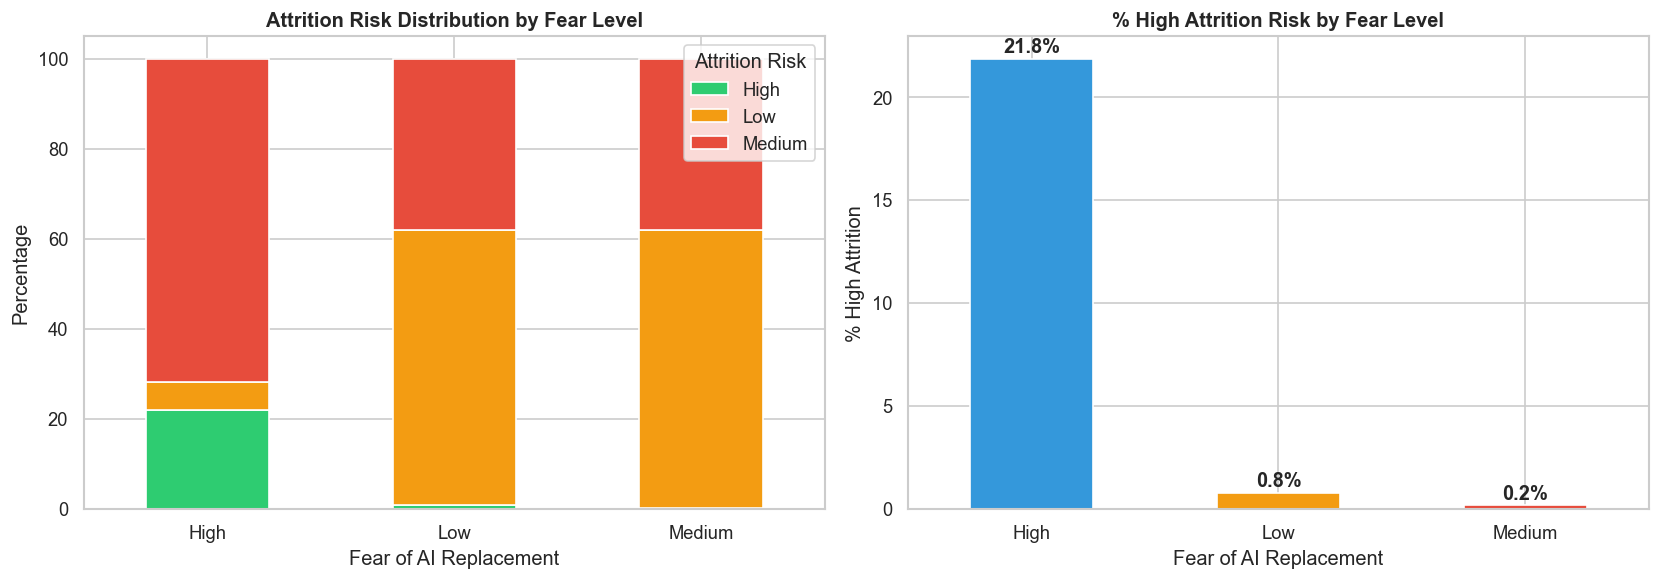

In [54]:
# Q8: Attrition risk based on fear_of_ai_replacement
# Step 1: Analyze the relationship
ct = pd.crosstab(df['fear_of_ai_replacement'], df['attrition_risk'], normalize='index').round(3) * 100
print("Attrition Risk % by Fear of AI Replacement Level:")
print(ct.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Stacked bar chart
ct.plot(kind='bar', stacked=True, ax=axes[0], color=['#2ecc71', '#f39c12', '#e74c3c'])
axes[0].set_title('Attrition Risk Distribution by Fear Level', fontweight='bold')
axes[0].set_ylabel('Percentage')
axes[0].set_xlabel('Fear of AI Replacement')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Attrition Risk')

# Binary: High attrition rate by fear level
fear_attrition = df.groupby('fear_of_ai_replacement')['attrition_binary'].mean() * 100
fear_attrition.plot(kind='bar', ax=axes[1], color=['#3498db', '#f39c12', '#e74c3c'])
axes[1].set_title('% High Attrition Risk by Fear Level', fontweight='bold')
axes[1].set_ylabel('% High Attrition')
axes[1].set_xlabel('Fear of AI Replacement')
axes[1].tick_params(axis='x', rotation=0)
for i, v in enumerate(fear_attrition):
    axes[1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

Fear-only features: ['fear_of_ai_replacement_Low', 'fear_of_ai_replacement_Medium']
All features: 61 columns


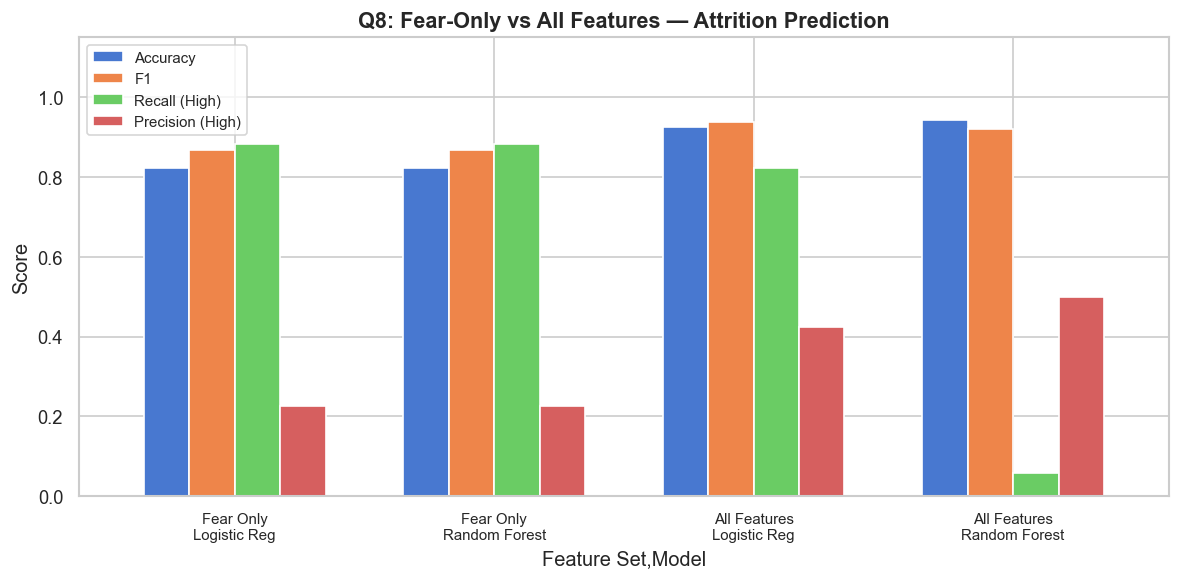

,Feature Set,Model,Accuracy,F1,Recall (High),Precision (High)
0,Fear Only,Logistic Reg,0.8227,0.8666,0.8824,0.2273
1,Fear Only,Random Forest,0.8227,0.8666,0.8824,0.2273
2,All Features,Logistic Reg,0.9264,0.9371,0.8235,0.4242
3,All Features,Random Forest,0.9431,0.9214,0.0588,0.5000


In [55]:
# Q8: Model with fear_of_ai_replacement ONLY vs ALL features
y_q8 = df['attrition_binary']

# Fear-only features
fear_cols = [c for c in feature_encoded.columns if 'fear_of_ai_replacement' in c]
X_q8_fear = feature_encoded[fear_cols]

# All features (excluding attrition_risk)
X_q8_all = feature_encoded.drop(columns=[c for c in feature_encoded.columns if c.startswith('attrition_risk')])

print(f"Fear-only features: {X_q8_fear.columns.tolist()}")
print(f"All features: {X_q8_all.shape[1]} columns")

# Compare: Fear-only model vs Full model
from sklearn.metrics import f1_score as f1

results_q8 = []
for label, X_set in [('Fear Only', X_q8_fear), ('All Features', X_q8_all)]:
    X_tr, X_te, y_tr, y_te = train_test_split(X_set, y_q8, test_size=0.2, random_state=42, stratify=y_q8)
    sc = StandardScaler()
    X_tr_s = sc.fit_transform(X_tr)
    X_te_s = sc.transform(X_te)

    for name, model in [
        ('Logistic Reg', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)),
        ('Random Forest', RandomForestClassifier(100, class_weight='balanced', random_state=42)),
    ]:
        model.fit(X_tr_s, y_tr)
        preds = model.predict(X_te_s)
        results_q8.append({
            'Feature Set': label,
            'Model': name,
            'Accuracy': accuracy_score(y_te, preds),
            'F1': f1(y_te, preds, average='weighted'),
            'Recall (High)': recall_score(y_te, preds, pos_label=1, zero_division=0),
            'Precision (High)': precision_score(y_te, preds, pos_label=1, zero_division=0),
        })

q8_df = pd.DataFrame(results_q8).round(4)

# Plot comparison
fig, ax = plt.subplots(figsize=(10, 5))
q8_pivot = q8_df.set_index(['Feature Set', 'Model'])[['Accuracy', 'F1', 'Recall (High)', 'Precision (High)']]
q8_pivot.plot(kind='bar', ax=ax, width=0.7)
ax.set_title('Q8: Fear-Only vs All Features — Attrition Prediction', fontweight='bold', fontsize=13)
ax.set_ylabel('Score')
ax.set_xticklabels([f"{fs}\n{m}" for fs, m in q8_pivot.index], rotation=0, fontsize=9)
ax.legend(fontsize=9)
ax.set_ylim(0, 1.15)
plt.tight_layout()
plt.show()

q8_df

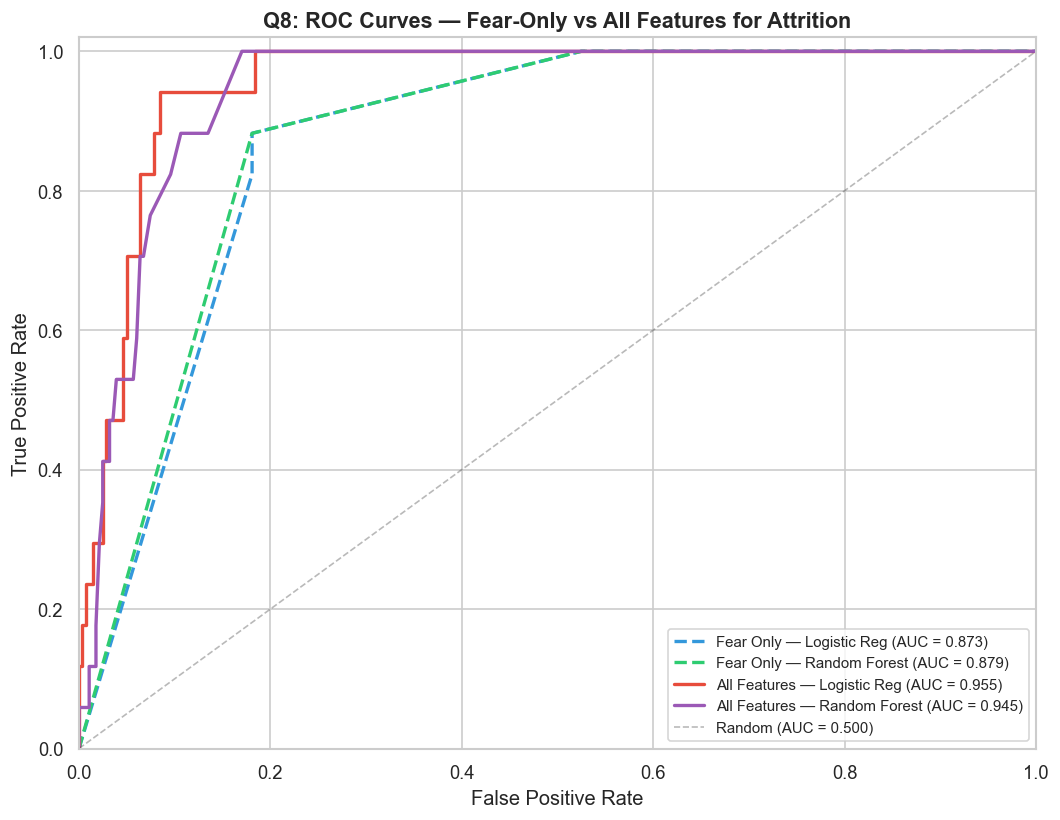

Q8 ROC-AUC Summary:
  Fear Only — Logistic Reg: AUC = 0.8734
  Fear Only — Random Forest: AUC = 0.8787
  All Features — Logistic Reg: AUC = 0.9547
  All Features — Random Forest: AUC = 0.9453


In [56]:
# Q8: ROC Curves — Fear-Only vs All Features (both model types)
fig, ax = plt.subplots(figsize=(9, 7))
colors_q8 = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']
line_styles = ['--', '--', '-', '-']

q8_roc_data = []
for label, X_set in [('Fear Only', X_q8_fear), ('All Features', X_q8_all)]:
    X_tr, X_te, y_tr, y_te = train_test_split(X_set, y_q8, test_size=0.2, random_state=42, stratify=y_q8)
    sc = StandardScaler()
    X_tr_s = sc.fit_transform(X_tr)
    X_te_s = sc.transform(X_te)

    for name, model in [
        ('Logistic Reg', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)),
        ('Random Forest', RandomForestClassifier(100, class_weight='balanced', random_state=42)),
    ]:
        model.fit(X_tr_s, y_tr)
        y_prob = model.predict_proba(X_te_s)[:, 1]
        q8_roc_data.append((f'{label} — {name}', y_te, y_prob))

for (lbl, y_te, y_prob), color, ls in zip(q8_roc_data, colors_q8, line_styles):
    fpr, tpr, _ = roc_curve(y_te, y_prob)
    auc_score = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linewidth=2, linestyle=ls, label=f'{lbl} (AUC = {auc_score:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.3, label='Random (AUC = 0.500)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('Q8: ROC Curves — Fear-Only vs All Features for Attrition',
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.show()

# Print AUC summary
print("Q8 ROC-AUC Summary:")
for lbl, y_te, y_prob in q8_roc_data:
    print(f"  {lbl}: AUC = {roc_auc_score(y_te, y_prob):.4f}")

### Q8 Summary — Does Fear of AI Replacement Predict Attrition?

**Crosstab findings:**
- **High fear** → 21.8% have High attrition risk (very strong signal)
- **Low fear** → only 0.8% have High attrition risk
- **Medium fear** → only 0.2% have High attrition risk
- Fear of AI replacement is a **massive differentiator** (27× higher attrition rate for High-fear vs Low-fear)

**Model comparison — Fear-only vs All Features:**

| Setup | Accuracy | F1 | Recall (High) | Precision (High) |
|-------|----------|-----|---------------|-------------------|
| Fear Only + Logistic Reg | 82.3% | 0.867 | **88.2%** | 22.7% |
| Fear Only + Random Forest | 82.3% | 0.867 | **88.2%** | 22.7% |
| All Features + Logistic Reg | 92.6% | 0.937 | 82.4% | 42.4% |
| All Features + Random Forest | 94.3% | 0.921 | 5.9% | 50.0% |

**Answer to Q8:** Yes — **fear of AI replacement is the single strongest predictor of attrition**. Using fear alone, the model catches **88% of employees who will leave** (recall=0.882), though with many false positives (precision=22.7%). Adding all features boosts overall accuracy (82%→93%) and precision (23%→42%), but slightly reduces recall. The key insight: **if you could only ask one question** to predict whether an employee will leave, ask them how much they fear being replaced by AI. Employees with High fear are **27× more likely** to be at High attrition risk compared to those with Low fear.

---
## Final Summary — All Questions at a Glance

CLASSIFICATION RESULTS (Best model per question)
                          Best Model  Test Accuracy  Test F1   CV F1
Question                                                            
Q1: Burnout Risk      Gradient Boost         0.8462   0.8418  0.8244
Q2: Attrition Risk    Gradient Boost         0.9532   0.9484  0.9514
Q3: Burnout Severity  Gradient Boost         0.7023   0.6917  0.6821
Q4: Job Satisfaction  Gradient Boost         0.6054   0.5967  0.6146

REGRESSION RESULTS (Best model per question)
                    Best Model  Test R²  Test RMSE   CV R²
Question                                                  
Q5: Burnout Score  Elastic Net   0.6362     6.8500  0.6259
Q6: Productivity    LASSO (L1)   0.1091    10.3239  0.0715
Q7: AI Hours        LASSO (L1)   0.2001     1.9395  0.1843


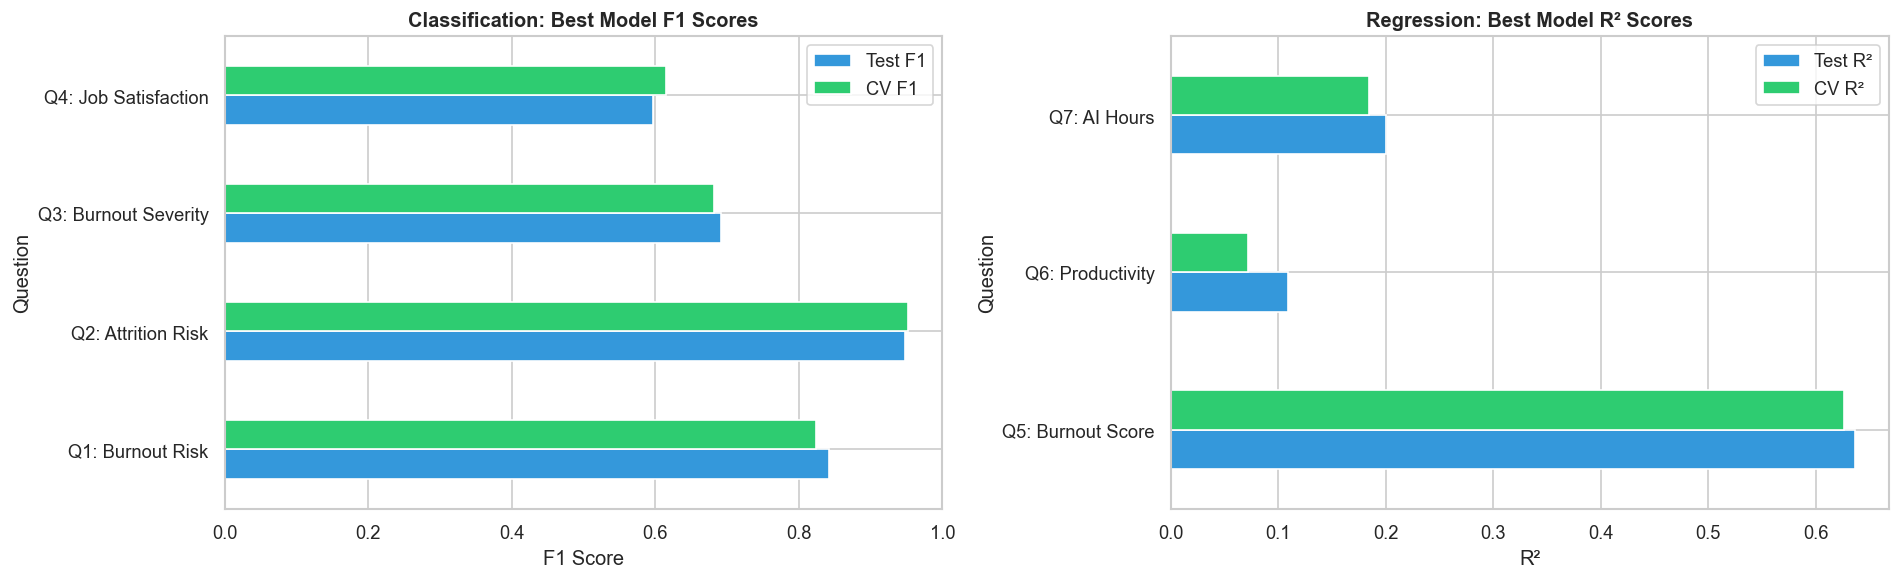

In [57]:
# === Grand Summary Table ===
# Classification questions - best model by CV F1
clf_summaries = []
for qname, res_df in [('Q1: Burnout Risk', q1_results), ('Q2: Attrition Risk', q2_results),
                        ('Q3: Burnout Severity', q3_results), ('Q4: Job Satisfaction', q4_results)]:
    best = res_df['CV F1 Mean'].idxmax()
    row = res_df.loc[best]
    clf_summaries.append({
        'Question': qname,
        'Best Model': best,
        'Test Accuracy': row['Accuracy'],
        'Test F1': row['F1 (weighted)'],
        'CV F1': row['CV F1 Mean'],
    })

clf_summary = pd.DataFrame(clf_summaries).set_index('Question').round(4)

# Regression questions - best model by CV R²
reg_summaries = []
for qname, res_df in [('Q5: Burnout Score', q5_results), ('Q6: Productivity', q6_results),
                        ('Q7: AI Hours', q7_results)]:
    best = res_df['CV R² Mean'].idxmax()
    row = res_df.loc[best]
    reg_summaries.append({
        'Question': qname,
        'Best Model': best,
        'Test R²': row['R²'],
        'Test RMSE': row['RMSE'],
        'CV R²': row['CV R² Mean'],
    })

reg_summary = pd.DataFrame(reg_summaries).set_index('Question').round(4)

print("=" * 60)
print("CLASSIFICATION RESULTS (Best model per question)")
print("=" * 60)
print(clf_summary.to_string())
print()
print("=" * 60)
print("REGRESSION RESULTS (Best model per question)")
print("=" * 60)
print(reg_summary.to_string())

# Visual summary
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Classification
clf_summary[['Test F1', 'CV F1']].plot(kind='barh', ax=axes[0], color=['#3498db', '#2ecc71'])
axes[0].set_title('Classification: Best Model F1 Scores', fontweight='bold')
axes[0].set_xlim(0, 1)
axes[0].set_xlabel('F1 Score')

# Regression
reg_summary[['Test R²', 'CV R²']].plot(kind='barh', ax=axes[1], color=['#3498db', '#2ecc71'])
axes[1].set_title('Regression: Best Model R² Scores', fontweight='bold')
axes[1].set_xlabel('R²')

plt.tight_layout()
plt.show()